# Köppen-Geiger气候分区数据探索 P=0的value都删了

本notebook用于读取和分析Köppen-Geiger气候分类数据，评估其是否适合用于GSA分区分析。

In [4]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 设置绘图样式
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("库导入成功！")

库导入成功！


## 1. 读取Köppen-Geiger分类数据

In [5]:
# 读取Köppen-Geiger数据
kg_path = Path('./../data/koppen_geiger_0p1.nc')
kg_data = xr.open_dataset(kg_path)

print("数据集基本信息：")
print(kg_data)
print("\n" + "="*80)

# 查看变量
print("\n变量列表：")
for var in kg_data.data_vars:
    print(f"  - {var}: {kg_data[var].dims}, shape={kg_data[var].shape}")

# 查看坐标
print("\n坐标信息：")
for coord in kg_data.coords:
    values = kg_data[coord].values
    print(f"  - {coord}: {len(values)} points, range=[{values.min():.2f}, {values.max():.2f}]")

数据集基本信息：
<xarray.Dataset> Size: 52MB
Dimensions:        (lon: 3600, lat: 1800)
Coordinates:
  * lon            (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.7 179.8 179.9
  * lat            (lat) float64 14kB 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
Data variables:
    kg_class       (lat, lon) float32 26MB ...
    kg_confidence  (lat, lon) float32 26MB ...
Attributes:
    history:  Created on 2024-02-19 07:55


变量列表：
  - kg_class: ('lat', 'lon'), shape=(1800, 3600)
  - kg_confidence: ('lat', 'lon'), shape=(1800, 3600)

坐标信息：
  - lon: 3600 points, range=[-179.95, 179.95]
  - lat: 1800 points, range=[-89.95, 89.95]


## 2. 分析气候分类的分布

In [6]:
# 读取legend映射
legend = {
    1: 'Af - Tropical, rainforest',
    2: 'Am - Tropical, monsoon',
    3: 'Aw - Tropical, savannah',
    4: 'BWh - Arid, desert, hot',
    5: 'BWk - Arid, desert, cold',
    6: 'BSh - Arid, steppe, hot',
    7: 'BSk - Arid, steppe, cold',
    8: 'Csa - Temperate, dry summer, hot summer',
    9: 'Csb - Temperate, dry summer, warm summer',
    10: 'Csc - Temperate, dry summer, cold summer',
    11: 'Cwa - Temperate, dry winter, hot summer',
    12: 'Cwb - Temperate, dry winter, warm summer',
    13: 'Cwc - Temperate, dry winter, cold summer',
    14: 'Cfa - Temperate, no dry season, hot summer',
    15: 'Cfb - Temperate, no dry season, warm summer',
    16: 'Cfc - Temperate, no dry season, cold summer',
    17: 'Dsa - Cold, dry summer, hot summer',
    18: 'Dsb - Cold, dry summer, warm summer',
    19: 'Dsc - Cold, dry summer, cold summer',
    20: 'Dsd - Cold, dry summer, very cold winter',
    21: 'Dwa - Cold, dry winter, hot summer',
    22: 'Dwb - Cold, dry winter, warm summer',
    23: 'Dwc - Cold, dry winter, cold summer',
    24: 'Dwd - Cold, dry winter, very cold winter',
    25: 'Dfa - Cold, no dry season, hot summer',
    26: 'Dfb - Cold, no dry season, warm summer',
    27: 'Dfc - Cold, no dry season, cold summer',
    28: 'Dfd - Cold, no dry season, very cold winter',
    29: 'ET - Polar, tundra',
    30: 'EF - Polar, frost'
}

print("Köppen-Geiger气候分类系统（30类）已加载")

Köppen-Geiger气候分类系统（30类）已加载


In [7]:
# 获取气候分类变量（假设变量名可能是'climate'、'koppen'或第一个数据变量）
var_name = list(kg_data.data_vars)[0]
climate_data = kg_data[var_name]

print(f"气候分类变量名: {var_name}")
print(f"数据形状: {climate_data.shape}")
print(f"数据类型: {climate_data.dtype}")
print(f"\n数值范围: {climate_data.min().values} - {climate_data.max().values}")

# 统计各类别的网格数
values = climate_data.values.flatten()
values_no_nan = values[~np.isnan(values)]

print(f"\n总网格数: {len(values)}")
print(f"有效网格数: {len(values_no_nan)}")
print(f"NaN网格数: {len(values) - len(values_no_nan)}")

# 统计每个气候类型的出现次数
unique, counts = np.unique(values_no_nan, return_counts=True)
climate_stats = pd.DataFrame({
    'Code': unique.astype(int),
    'Count': counts,
    'Percentage': counts / len(values_no_nan) * 100
})
climate_stats['Climate_Type'] = climate_stats['Code'].map(legend)
climate_stats = climate_stats.sort_values('Count', ascending=False)

print("\n各气候类型分布：")
print(climate_stats.to_string(index=False))

气候分类变量名: kg_class
数据形状: (1800, 3600)
数据类型: float32

数值范围: 0.0 - 30.0

总网格数: 6480000
有效网格数: 6480000
NaN网格数: 0

各气候类型分布：
 Code   Count  Percentage                                Climate_Type
    0 4268934   65.878611                                         NaN
   30  666267   10.281898                           EF - Polar, frost
   27  266833    4.117793      Dfc - Cold, no dry season, cold summer
    4  200752    3.098025                     BWh - Arid, desert, hot
    3  150591    2.323935                     Aw - Tropical, savannah
   29  149192    2.302346                          ET - Polar, tundra
   26  124660    1.923765      Dfb - Cold, no dry season, warm summer
    7   90464    1.396049                    BSk - Arid, steppe, cold
    5   75185    1.160262                    BWk - Arid, desert, cold
    6   74499    1.149676                     BSh - Arid, steppe, hot
    1   62064    0.957778                   Af - Tropical, rainforest
   14   59648    0.920494  Cfa - Temperat

/Users/mimi/miniconda3/envs/pip39/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 27668 (\N{CJK UNIFIED IDEOGRAPH-6C14}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mimi/miniconda3/envs/pip39/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20505 (\N{CJK UNIFIED IDEOGRAPH-5019}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mimi/miniconda3/envs/pip39/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mimi/miniconda3/envs/pip39/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mimi/miniconda3/envs/pip39/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph

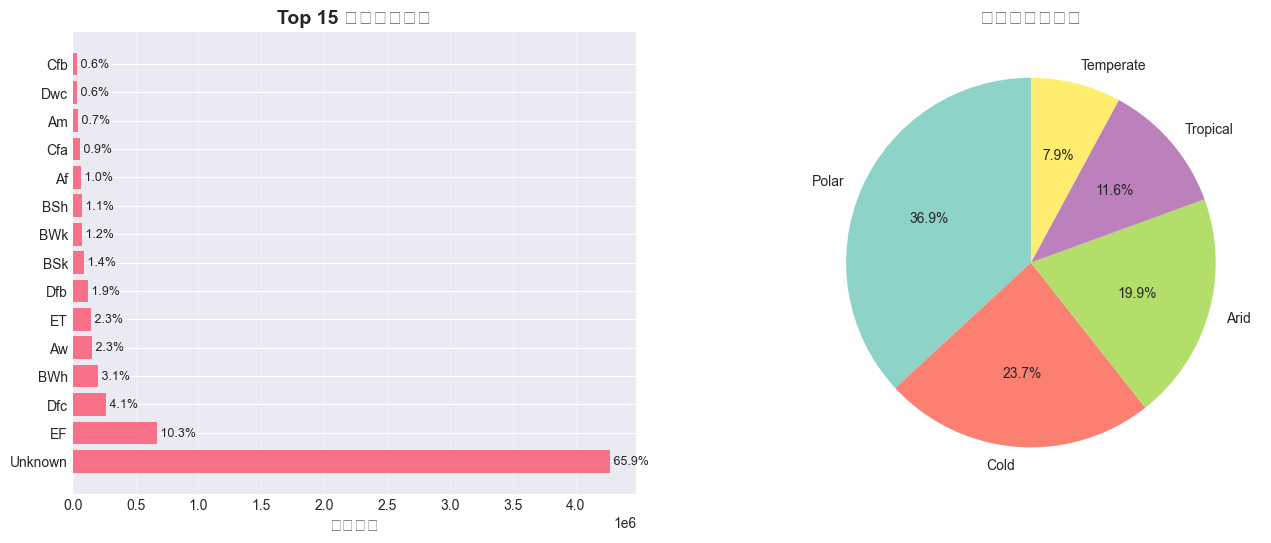


主要气候带统计：
Main_Group
Polar        815459
Cold         524943
Arid         440900
Tropical     255393
Temperate    174371
Name: Count, dtype: int64


In [8]:
# 可视化气候类型分布
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：柱状图显示各类型数量
ax1 = axes[0]
climate_stats_top15 = climate_stats.head(15)
bars = ax1.barh(range(len(climate_stats_top15)), climate_stats_top15['Count'])
ax1.set_yticks(range(len(climate_stats_top15)))
ax1.set_yticklabels([
    name.split(' - ')[0] if isinstance(name, str) else 'Unknown'
    for name in climate_stats_top15['Climate_Type']
])
ax1.set_xlabel('网格数量', fontsize=12)
ax1.set_title('Top 15 气候类型分布', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 添加百分比标签
for i, (count, pct) in enumerate(zip(climate_stats_top15['Count'], climate_stats_top15['Percentage'])):
    ax1.text(count, i, f' {pct:.1f}%', va='center', fontsize=9)

# 右图：按主要气候带分组
ax2 = axes[1]
climate_stats['Main_Group'] = climate_stats['Climate_Type'].str.split(' - ').str[1].str.split(',').str[0]
group_stats = climate_stats.groupby('Main_Group')['Count'].sum().sort_values(ascending=False)

colors = plt.cm.Set3(np.linspace(0, 1, len(group_stats)))
wedges, texts, autotexts = ax2.pie(group_stats.values, labels=group_stats.index, autopct='%1.1f%%',
                                     startangle=90, colors=colors, textprops={'fontsize': 10})
ax2.set_title('主要气候带分布', fontsize=14, fontweight='bold')

# plt.tight_layout()
# plt.savefig('output/koppen_geiger_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n主要气候带统计：")
print(group_stats)

## 3. 检查空间分辨率和覆盖范围

In [9]:
# 检查坐标系统
lat_name = [c for c in kg_data.coords if 'lat' in c.lower()][0]
lon_name = [c for c in kg_data.coords if 'lon' in c.lower()][0]

lats = kg_data[lat_name].values
lons = kg_data[lon_name].values

print("空间信息：")
print(f"  经度: {len(lons)} points, [{lons.min():.2f}, {lons.max():.2f}]")
print(f"  纬度: {len(lats)} points, [{lats.min():.2f}, {lats.max():.2f}]")

# 计算分辨率
if len(lons) > 1:
    lon_res = np.median(np.diff(lons))
    print(f"  经度分辨率: {lon_res:.4f}° (~{lon_res:.1f}°)")

if len(lats) > 1:
    lat_res = np.median(np.diff(lats))
    print(f"  纬度分辨率: {lat_res:.4f}° (~{abs(lat_res):.1f}°)")

print("\n对比我们的数据：")
print("  降水数据: 0.1°分辨率, -59.95 to 89.95°")
print("  模型数据: 0.5°分辨率, -59.75 to 89.75° (已裁剪后)")

空间信息：
  经度: 3600 points, [-179.95, 179.95]
  纬度: 1800 points, [-89.95, 89.95]
  经度分辨率: 0.1000° (~0.1°)
  纬度分辨率: -0.1000° (~0.1°)

对比我们的数据：
  降水数据: 0.1°分辨率, -59.95 to 89.95°
  模型数据: 0.5°分辨率, -59.75 to 89.75° (已裁剪后)


## 4. 可视化气候分区空间分布

/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_27629/3563513173.py:37: UserWarning: Glyph 32463 (\N{CJK UNIFIED IDEOGRAPH-7ECF}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_27629/3563513173.py:37: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_27629/3563513173.py:37: UserWarning: Glyph 32428 (\N{CJK UNIFIED IDEOGRAPH-7EAC}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_27629/3563513173.py:37: UserWarning: Glyph 27668 (\N{CJK UNIFIED IDEOGRAPH-6C14}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_27629/3563513173.py:37: UserWarning: Glyph 20505 (\N{CJK UNIFIED IDEOGRAPH-5019}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/i

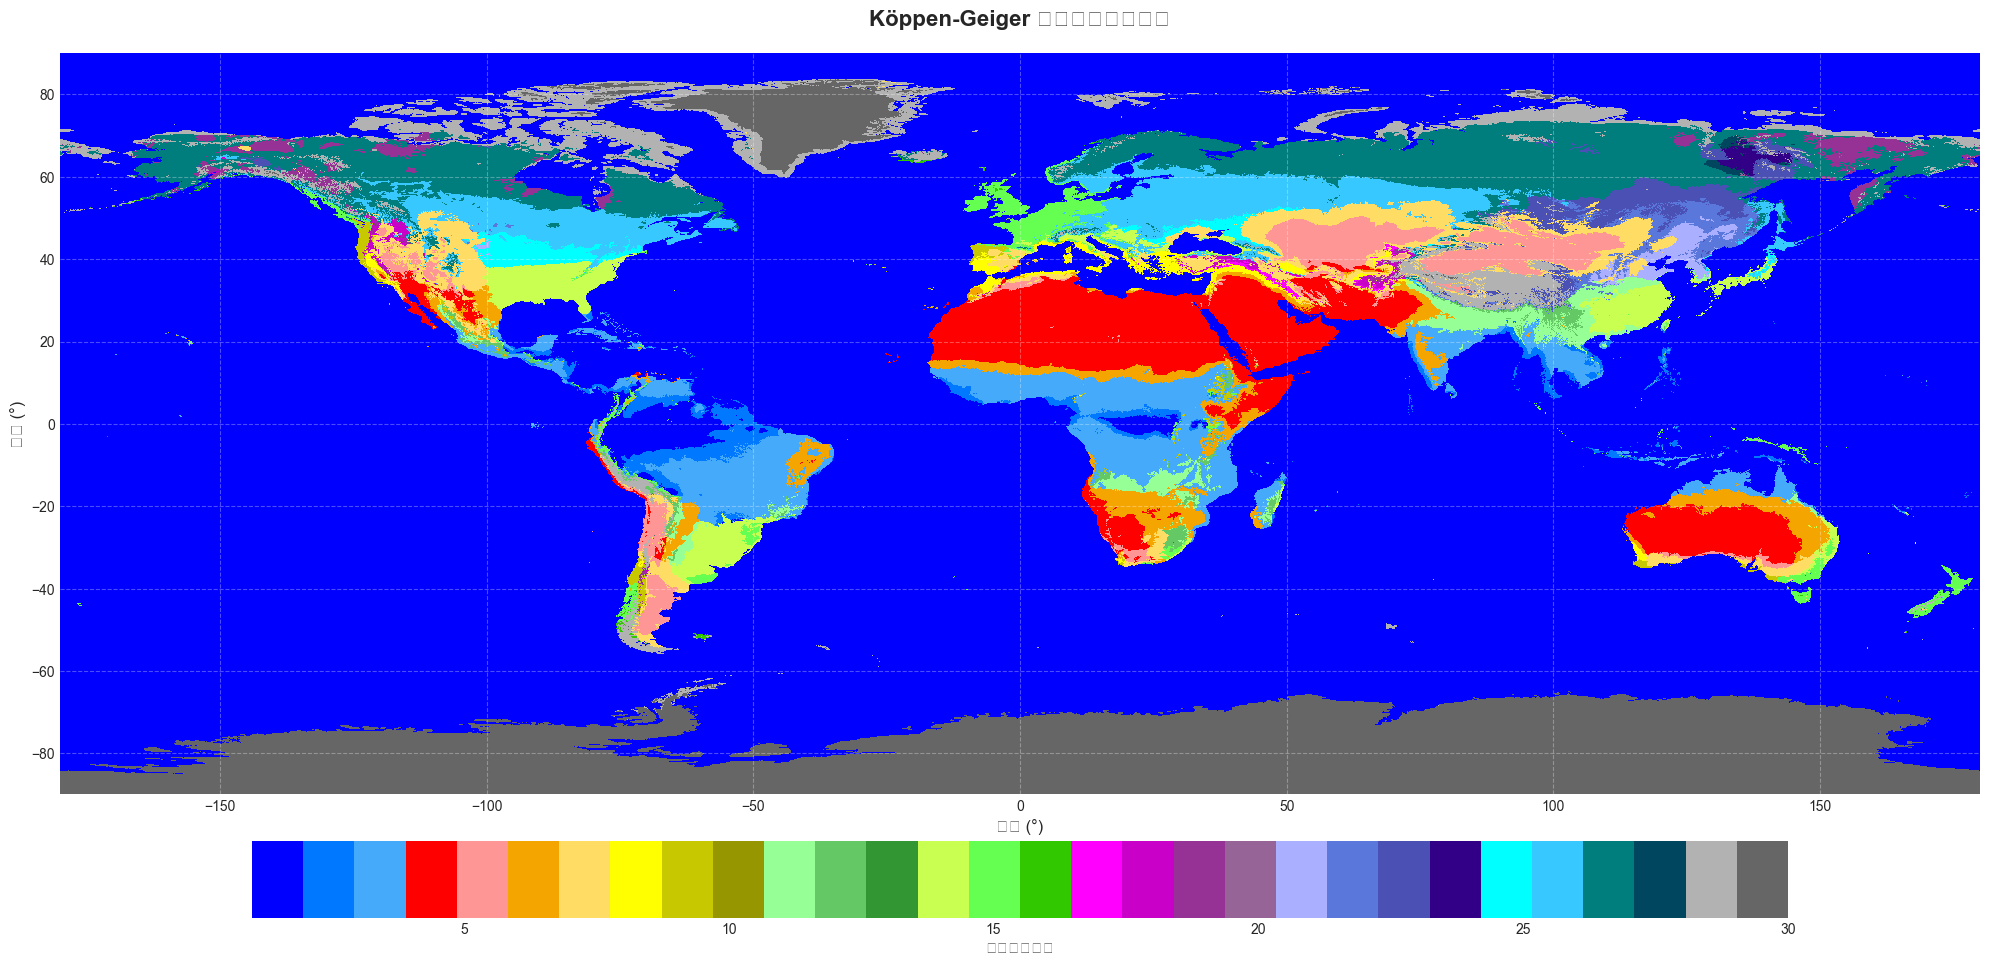

In [10]:
# 绘制全球气候分区地图
fig, ax = plt.subplots(figsize=(20, 10))

# 创建颜色映射（使用legend中定义的RGB颜色）
rgb_colors = [
    [0, 0, 255], [0, 120, 255], [70, 170, 250],  # Tropical
    [255, 0, 0], [255, 150, 150], [245, 165, 0], [255, 220, 100],  # Arid
    [255, 255, 0], [200, 200, 0], [150, 150, 0],  # Csa-Csc
    [150, 255, 150], [100, 200, 100], [50, 150, 50],  # Cwa-Cwc
    [200, 255, 80], [100, 255, 80], [50, 200, 0],  # Cfa-Cfc
    [255, 0, 255], [200, 0, 200], [150, 50, 150], [150, 100, 150],  # Dsa-Dsd
    [170, 175, 255], [90, 120, 220], [75, 80, 180], [50, 0, 135],  # Dwa-Dwd
    [0, 255, 255], [55, 200, 255], [0, 125, 125], [0, 70, 95],  # Dfa-Dfd
    [178, 178, 178], [102, 102, 102]  # Polar
]

# 转换为0-1范围
cmap_colors = [[r/255, g/255, b/255] for r, g, b in rgb_colors]

from matplotlib.colors import ListedColormap
cmap = ListedColormap(cmap_colors)

# 绘制地图
im = ax.imshow(climate_data.values, cmap=cmap, vmin=1, vmax=30, 
               extent=[lons.min(), lons.max(), lats.min(), lats.max()],
               aspect='auto', interpolation='nearest')

ax.set_xlabel('经度 (°)', fontsize=12)
ax.set_ylabel('纬度 (°)', fontsize=12)
ax.set_title('Köppen-Geiger 气候分类全球分布', fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')

# 添加颜色条（仅显示主要类型）
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
cbar.set_label('气候类型编码', fontsize=11)

plt.tight_layout()
# plt.savefig('output/koppen_geiger_map.png', dpi=300, bbox_inches='tight')
plt.show()

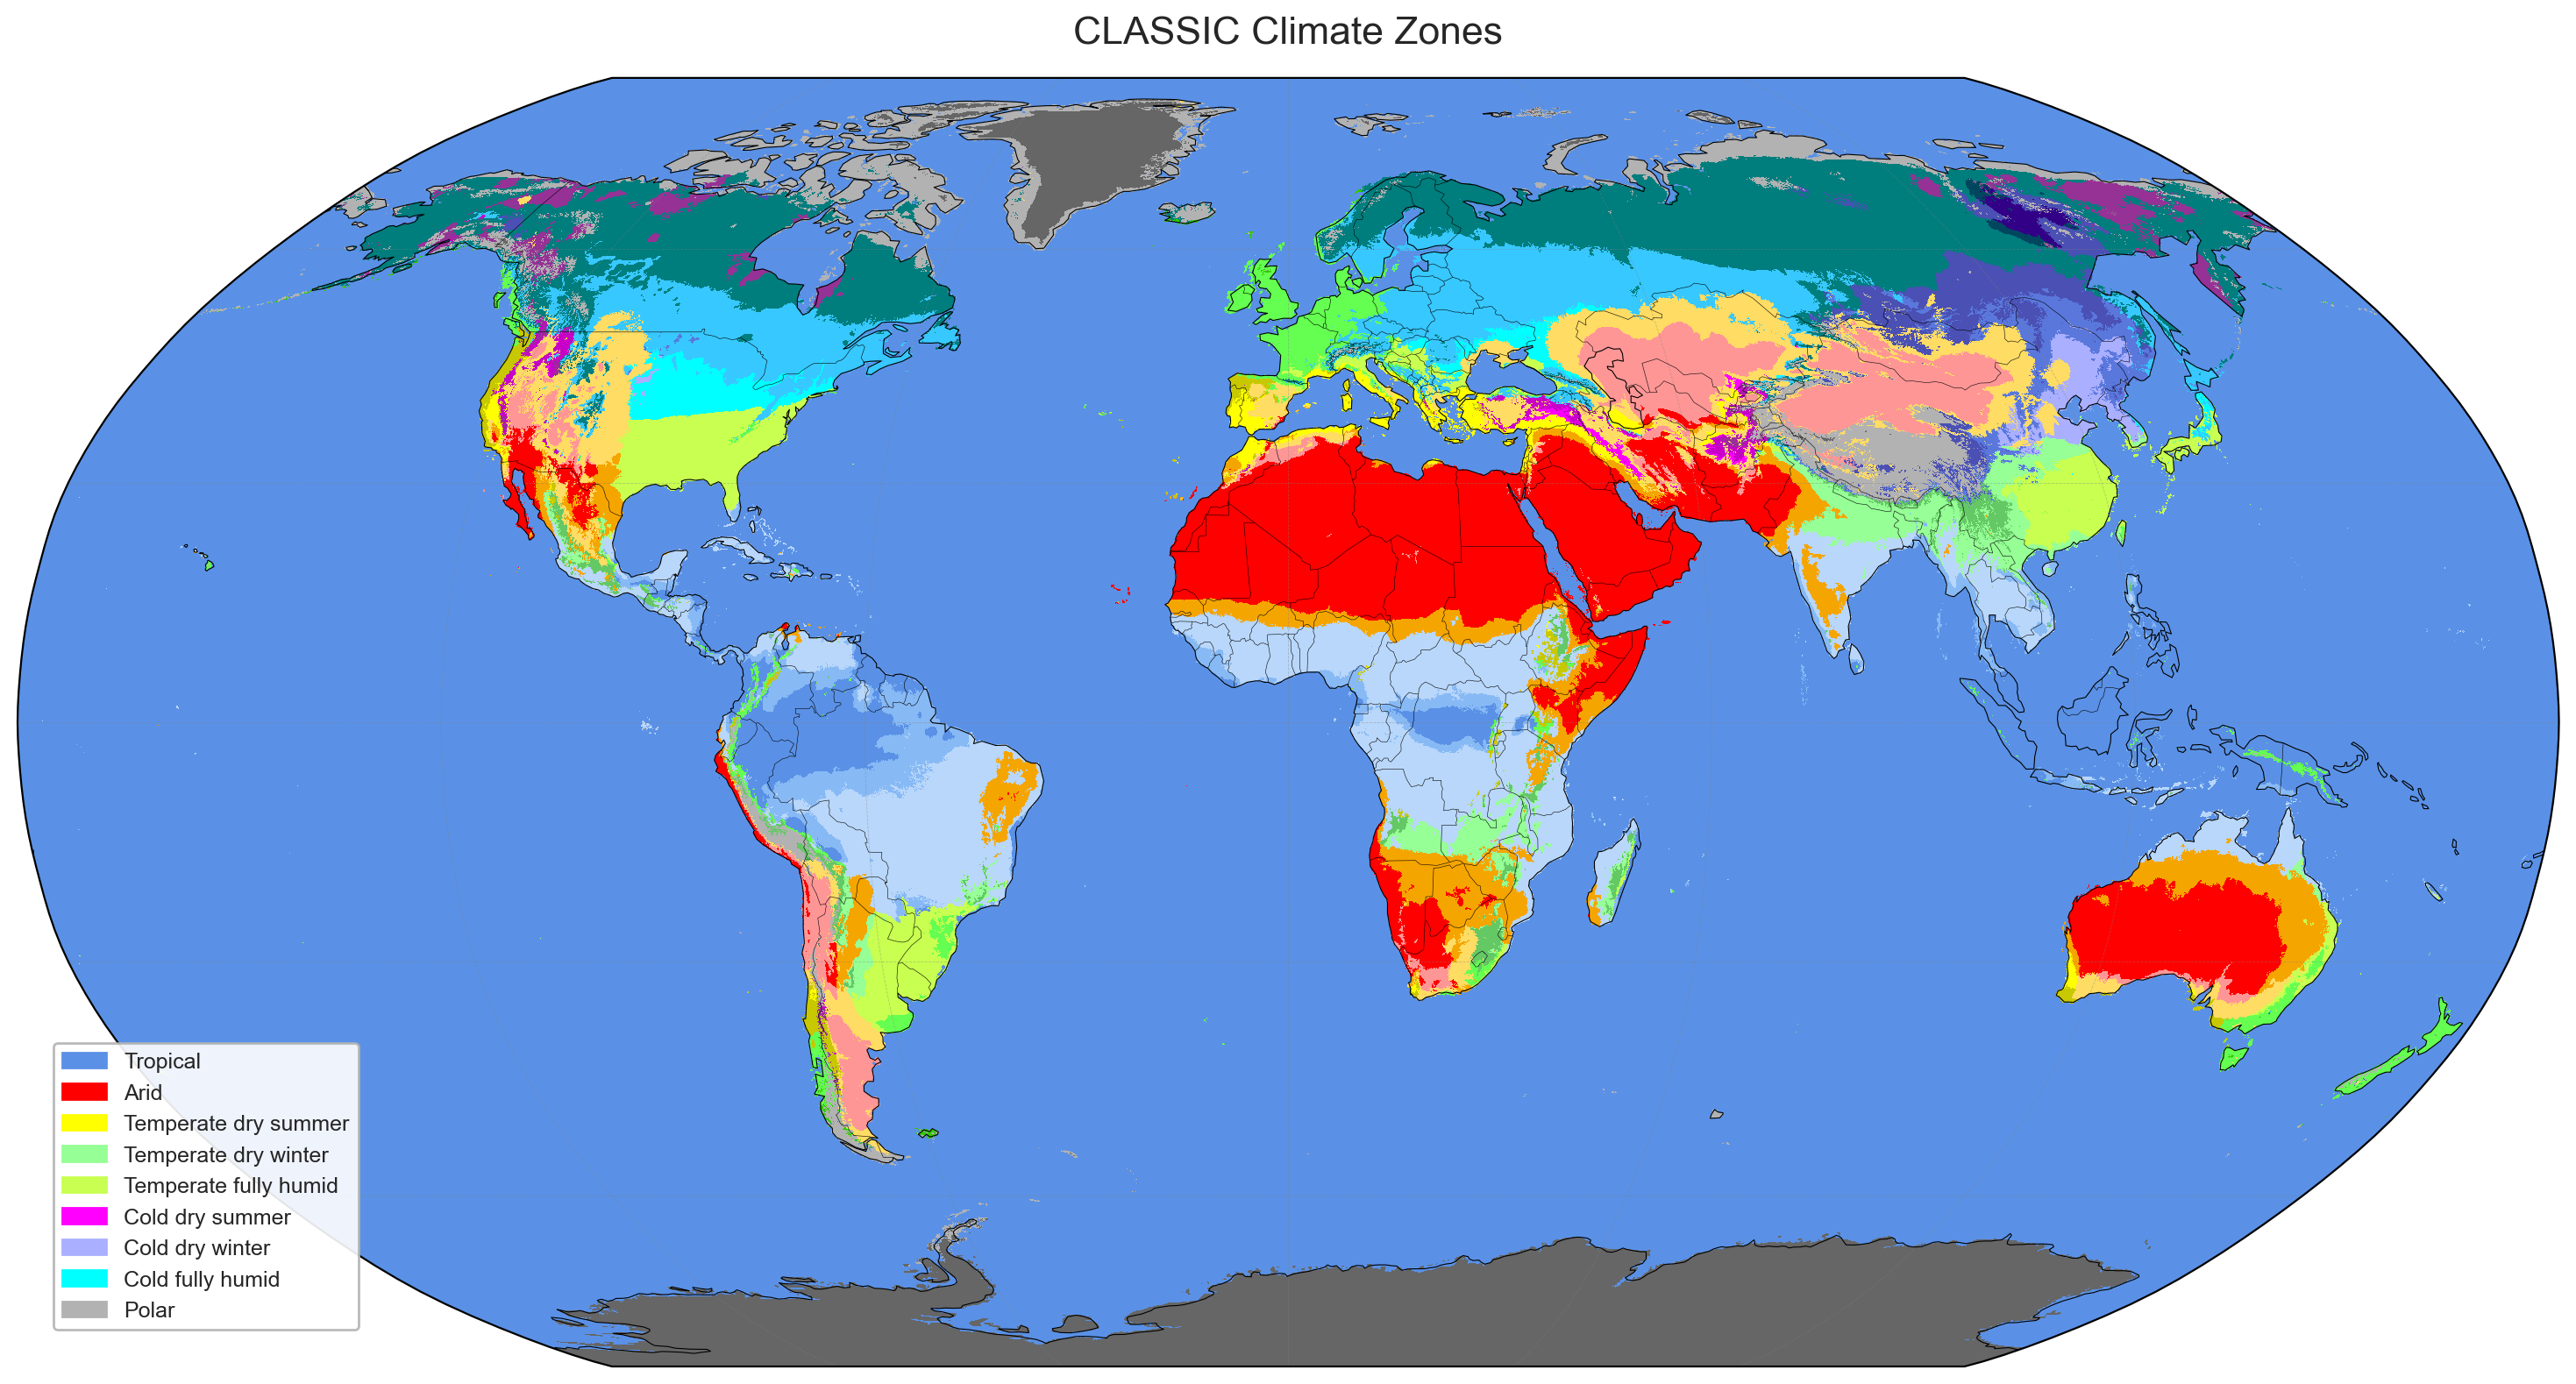

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# -----------------------------
# 1. 颜色
# -----------------------------
rgb_colors = [
    [90, 145, 230], [135, 185, 245], [185, 215, 250],   # Tropical ,  # Tropical
    [255, 0, 0], [255, 150, 150], [245, 165, 0], [255, 220, 100],  # Arid
    [255, 255, 0], [200, 200, 0], [150, 150, 0],         # Csa-Csc
    [150, 255, 150], [100, 200, 100], [50, 150, 50],     # Cwa-Cwc
    [200, 255, 80], [100, 255, 80], [50, 200, 0],        # Cfa-Cfc
    [255, 0, 255], [200, 0, 200], [150, 50, 150], [150, 100, 150], # Dsa-Dsd
    [170, 175, 255], [90, 120, 220], [75, 80, 180], [50, 0, 135],   # Dwa-Dwd
    [0, 255, 255], [55, 200, 255], [0, 125, 125], [0, 70, 95],      # Dfa-Dfd
    [178, 178, 178], [102, 102, 102]  # Polar
]
cmap_colors = np.array(rgb_colors) / 255.0
cmap = ListedColormap(cmap_colors)

# 假设 climate_data.values 的类别编码是 1~30
bounds = np.arange(0.5, 30.5 + 1, 1)
norm = BoundaryNorm(bounds, cmap.N)

# -----------------------------
# 2. 构造网格
# lons, lats 为 1D 数组
# climate_data.values shape = (len(lats), len(lons))
# -----------------------------
lon2d, lat2d = np.meshgrid(lons, lats)

# -----------------------------
# 3. 地图投影
# -----------------------------
fig = plt.figure(figsize=(16, 8), dpi=200)
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

# 背景
ax.set_facecolor("white")

# 底图要素
ax.add_feature(cfeature.LAND, facecolor="#f2f2f2", edgecolor="none", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
ax.coastlines(linewidth=0.4, color="black", zorder=3)
ax.add_feature(cfeature.BORDERS, linewidth=0.2, edgecolor="black", zorder=3)

# 椭圆边框风格更接近示例图
# 椭圆外边框
if hasattr(ax, "outline_patch"):
    ax.outline_patch.set_linewidth(0.8)
elif hasattr(ax, "spines") and "geo" in ax.spines:
    ax.spines["geo"].set_linewidth(0.8)
    ax.spines["geo"].set_edgecolor("black")

# -----------------------------
# 4. 绘制分类图
# pcolormesh 比 imshow 更适合经纬度地图
# -----------------------------
mesh = ax.pcolormesh(
    lon2d,
    lat2d,
    climate_data.values,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree(),
    shading="auto",
    zorder=1
)

# -----------------------------
# 5. 经纬网
# -----------------------------
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    linewidth=0.3,
    color="gray",
    alpha=0.4,
    linestyle="--"
)

# -----------------------------
# 6. 标题
# -----------------------------
ax.set_title(
    "CLASSIC Climate Zones",
    fontsize=16,
    pad=14
)

# -----------------------------
# 7. 离散图例（比 colorbar 好看）
# 这里建议按大类合并，而不是 30 个全列出来
# -----------------------------
legend_items = [
    ("Tropical", cmap_colors[0]),
    ("Arid", cmap_colors[3]),
    ("Temperate dry summer", cmap_colors[7]),
    ("Temperate dry winter", cmap_colors[10]),
    ("Temperate fully humid", cmap_colors[13]),
    ("Cold dry summer", cmap_colors[16]),
    ("Cold dry winter", cmap_colors[20]),
    ("Cold fully humid", cmap_colors[24]),
    ("Polar", cmap_colors[28]),
]

patches = [
    mpatches.Patch(color=color, label=label)
    for label, color in legend_items
]

ax.legend(
    handles=patches,
    loc="lower left",
    bbox_to_anchor=(0.01, 0.02),
    fontsize=9,
    frameon=True,
    framealpha=0.9,
    facecolor="white",
    edgecolor="0.7",
    ncol=1
)

plt.tight_layout()
plt.show()

## 5. 评估数据对齐的可行性

In [12]:
print("数据对齐评估：\n" + "="*80)

# 1. 空间分辨率对比
print("\n1. 空间分辨率：")
print(f"   Köppen-Geiger: ~{abs(lat_res):.1f}° x {lon_res:.1f}°")
print(f"   降水数据:      0.1° x 0.1°")
print(f"   模型数据:      0.5° x 0.5°")
print(f"   ✓ Köppen数据可以重采样到0.5°以匹配模型数据")

# 2. 空间覆盖范围对比
print("\n2. 空间覆盖范围：")
print(f"   Köppen-Geiger: 纬度 [{lats.min():.2f}, {lats.max():.2f}]")
print(f"   模型数据(裁剪后): 纬度 [-59.75, 89.75]")

if lats.min() <= -59.75 and lats.max() >= 89.75:
    print(f"   ✓ Köppen数据完全覆盖模型数据的空间范围")
else:
    print(f"   ✗ 覆盖范围不完全匹配，需要检查")

# 3. 数据质量
print("\n3. 数据质量：")
valid_ratio = len(values_no_nan) / len(values) * 100
print(f"   有效数据比例: {valid_ratio:.2f}%")
print(f"   气候类型数量: {len(unique)} 类")
print(f"   ✓ 数据质量良好")

# 4. 分组建议
print("\n4. 分组方案建议：")
print("   方案A - 按主要气候带（5类）：")
print("     1. Tropical (A)     - 热带气候")
print("     2. Arid (B)         - 干旱气候")
print("     3. Temperate (C)    - 温带气候")
print("     4. Cold (D)         - 寒带气候")
print("     5. Polar (E)        - 极地气候")
print("\n   方案B - 按水分条件（3类）：")
print("     1. 湿润区: A, Cf, Df (无干季)")
print("     2. 干旱区: B (沙漠和草原)")
print("     3. 季节性干湿: Cw, Cs, Dw, Ds (有干季)")
print("\n   方案C - 按温度-水分组合（简化版）：")
print("     1. 热带湿润: Af, Am")
print("     2. 热带季节性: Aw")
print("     3. 干旱: BW, BS")
print("     4. 温带湿润: Cfa, Cfb, Cfc")
print("     5. 温带干季: Csa, Csb, Cwa, Cwb")
print("     6. 寒带: D类")
print("     7. 极地: E类")

数据对齐评估：

1. 空间分辨率：
   Köppen-Geiger: ~0.1° x 0.1°
   降水数据:      0.1° x 0.1°
   模型数据:      0.5° x 0.5°
   ✓ Köppen数据可以重采样到0.5°以匹配模型数据

2. 空间覆盖范围：
   Köppen-Geiger: 纬度 [-89.95, 89.95]
   模型数据(裁剪后): 纬度 [-59.75, 89.75]
   ✓ Köppen数据完全覆盖模型数据的空间范围

3. 数据质量：
   有效数据比例: 100.00%
   气候类型数量: 31 类
   ✓ 数据质量良好

4. 分组方案建议：
   方案A - 按主要气候带（5类）：
     1. Tropical (A)     - 热带气候
     2. Arid (B)         - 干旱气候
     3. Temperate (C)    - 温带气候
     4. Cold (D)         - 寒带气候
     5. Polar (E)        - 极地气候

   方案B - 按水分条件（3类）：
     1. 湿润区: A, Cf, Df (无干季)
     2. 干旱区: B (沙漠和草原)
     3. 季节性干湿: Cw, Cs, Dw, Ds (有干季)

   方案C - 按温度-水分组合（简化版）：
     1. 热带湿润: Af, Am
     2. 热带季节性: Aw
     3. 干旱: BW, BS
     4. 温带湿润: Cfa, Cfb, Cfc
     5. 温带干季: Csa, Csb, Cwa, Cwb
     6. 寒带: D类
     7. 极地: E类


## 7. 创建4分类气候区（热湿、热干、冷湿、冷干）

In [13]:
# 定义30类到4类的映射
# HW=热湿, HD=热干, CW=冷湿, CD=冷干
climate_4groups = {
    # 热湿 (Hot-Humid): A类 - 热带
    1: 'HW',   # Af - 热带雨林
    2: 'HW',   # Am - 热带季风
    3: 'HW',   # Aw - 热带草原
    11: 'HW',  # Cwa
    14: 'HW',  # Cfa
    
    # 热干 (Hot-Arid): B类 - 干旱
    4: 'HD',   # BWh - 热沙漠
    6: 'HD',   # BSh - 热草原
    8: 'HD',   # BSk - 冷草原
    9: 'HD',   # BSk - 冷草原
    10: 'HD',  # BSk - 冷草原

    
    
    # 冷湿 (Cold-Humid): Cf + Df - 无干季
    12: 'CW',  # Cwb
    13: 'CW',  # Cwc
    15: 'CW',  # Cfb
    16: 'CW',  # Cfc
    17: 'CW',  # Dsa
    18: 'CW',  # Dsb
    19: 'CW',  # Dsc
    20: 'CW',  # Dsd
    21: 'CW',  # Dwa
    22: 'CW',  # Dwb
    23: 'CW',  # Dwc
    24: 'CW',  # Dwd
    25: 'CW',  # Dfa
    26: 'CW',  # Dfb
    27: 'CW',  # Dfc
    28: 'CW',  # Dfd
    
    # 冷干 (Cold-Dry): Cs + Cw + Ds + Dw + E - 有干季或极地
    5: 'CD',   # Csa
    7: 'CD',   # Csb
    29: 'CD',  # ET - 极地苔原
    30: 'CD',  # EF - 极地冰霜

    
    0: 'Unknown'  # 海洋或无数据
}

# 应用映射创建4分类数据
climate_4class = climate_data.copy()
climate_4class_values = np.vectorize(lambda x: climate_4groups.get(int(x) if not np.isnan(x) else 0, 'Unknown'))(climate_data.values)

print("4分类气候区映射已创建")
print("\n分类统计：")
unique_4class, counts_4class = np.unique(climate_4class_values, return_counts=True)
stats_4class = pd.DataFrame({
    'Climate_Zone': unique_4class,
    'Count': counts_4class,
    'Percentage': counts_4class / len(climate_4class_values.flatten()) * 100
})
stats_4class = stats_4class.sort_values('Count', ascending=False)
print(stats_4class.to_string(index=False))

# 创建4分类的xarray DataArray
climate_4class_da = xr.DataArray(
    climate_4class_values,
    coords={'lat': kg_data.lat, 'lon': kg_data.lon},
    dims=['lat', 'lon'],
    name='climate_zone_4class'
)

print("\n✓ 4分类气候区数据已创建")

4分类气候区映射已创建

分类统计：
Climate_Zone   Count  Percentage
     Unknown 4268934   65.878611
          CD  981108   15.140556
          CW  577392    8.910370
          HW  351497    5.424336
          HD  301069    4.646127

✓ 4分类气候区数据已创建


### 7.1 可视化4分类气候区分布

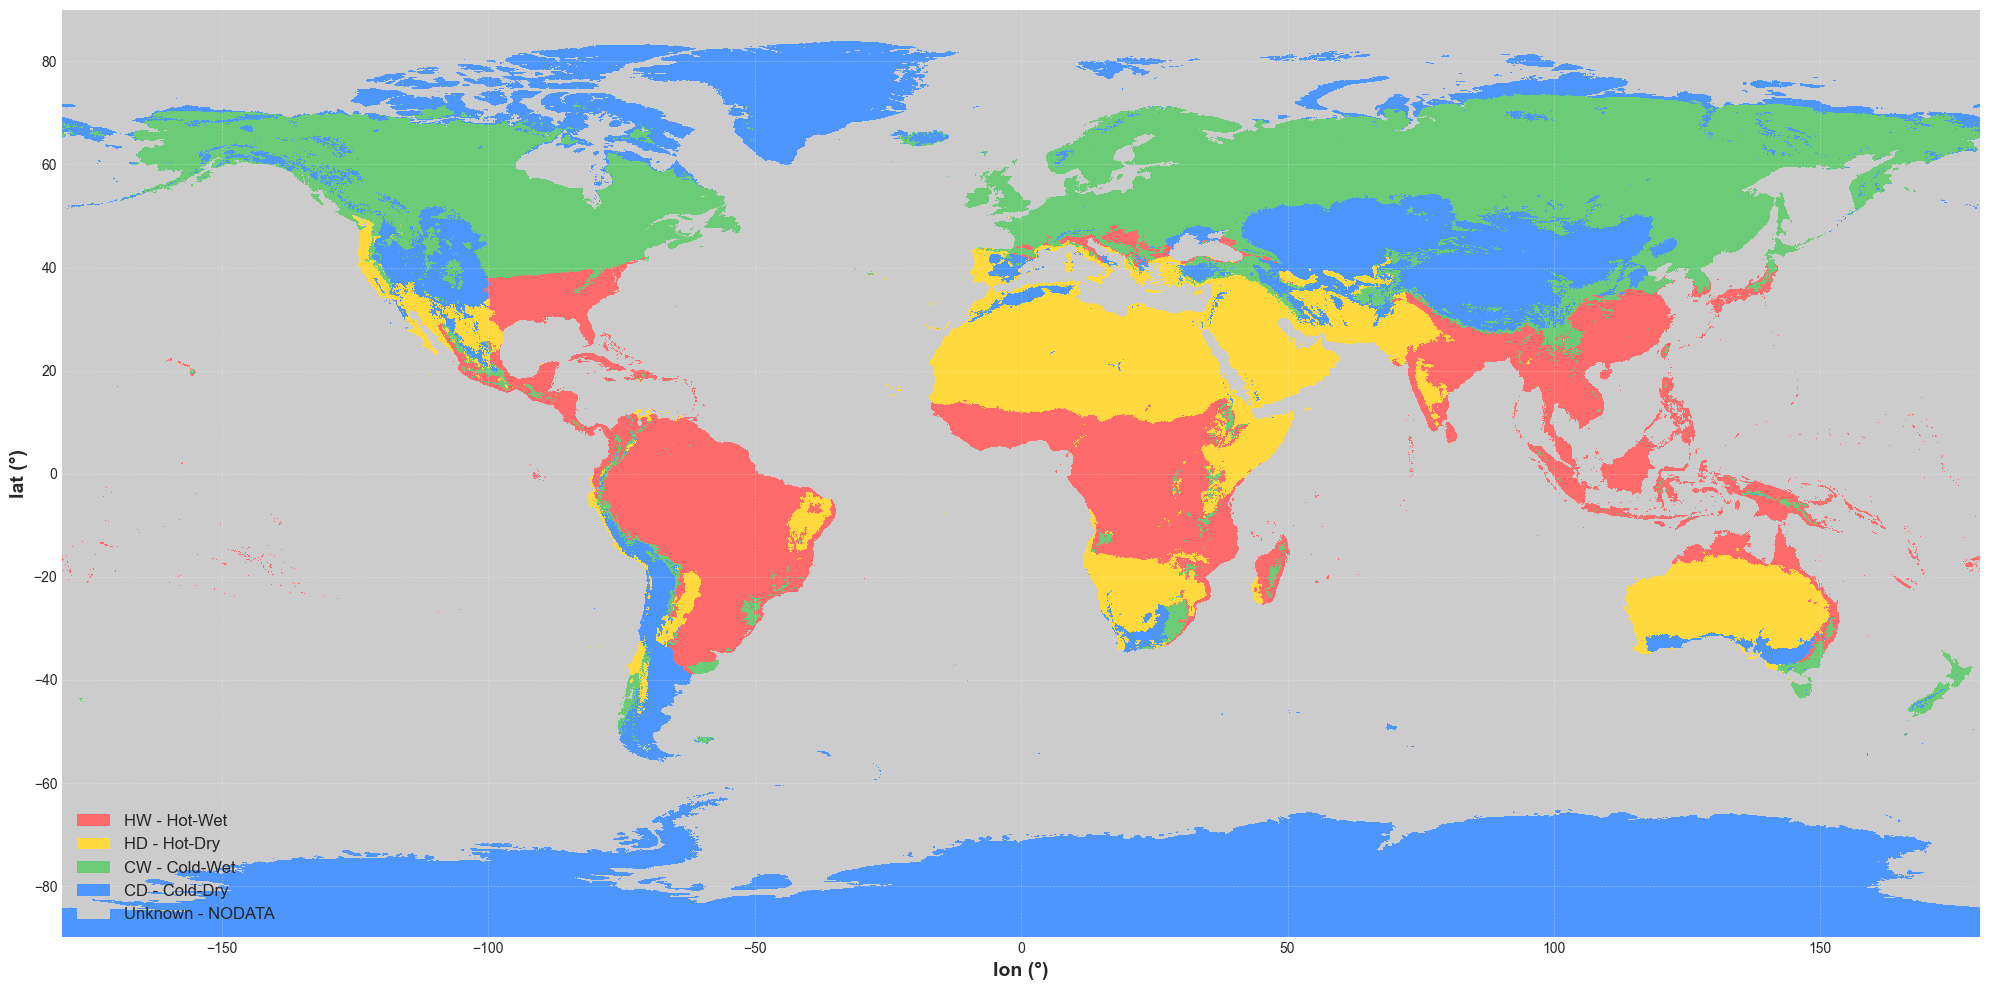

✓ 4分类气候区全球分布图已生成


In [14]:
# 创建4分类气候区的全球分布地图
fig, ax = plt.subplots(figsize=(20, 10))

# 定义4类的颜色映射
color_map_4class = {
    'HW': '#FF6B6B',  # 热湿 - 红色
    'HD': '#FFD93D',  # 热干 - 黄色
    'CW': '#6BCB77',  # 冷湿 - 绿色
    'CD': '#4D96FF',  # 冷干 - 蓝色
    'Unknown': '#CCCCCC'  # 未知 - 灰色
}

# 创建数值映射用于绘图
zone_to_num = {'HW': 1, 'HD': 2, 'CW': 3, 'CD': 4, 'Unknown': 0}
num_array = np.vectorize(lambda x: zone_to_num.get(x, 0))(climate_4class_values)

# 创建自定义颜色映射
from matplotlib.colors import ListedColormap, BoundaryNorm
colors_list = [color_map_4class['Unknown'], color_map_4class['HW'], 
               color_map_4class['HD'], color_map_4class['CW'], color_map_4class['CD']]
cmap_4class = ListedColormap(colors_list)
bounds = [0, 1, 2, 3, 4, 5]
norm = BoundaryNorm(bounds, cmap_4class.N)

# 绘制地图
im = ax.imshow(num_array, cmap=cmap_4class, norm=norm,
               extent=[lons.min(), lons.max(), lats.min(), lats.max()],
               aspect='auto', interpolation='nearest')

ax.set_xlabel('lon (°)', fontsize=14, fontweight='bold')
ax.set_ylabel('lat (°)', fontsize=14, fontweight='bold')
# ax.set_title('4分类气候区全球分布图', fontsize=18, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# 添加图例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color_map_4class['HW'], label='HW - Hot-Wet'),
    Patch(facecolor=color_map_4class['HD'], label='HD - Hot-Dry'),
    Patch(facecolor=color_map_4class['CW'], label='CW - Cold-Wet'),
    Patch(facecolor=color_map_4class['CD'], label='CD - Cold-Dry'),
    Patch(facecolor=color_map_4class['Unknown'], label='Unknown - NODATA')
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=12, 
          framealpha=0.9, edgecolor='black')

plt.tight_layout()
# plt.savefig('output/climate_zones_4class_map.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 4分类气候区全球分布图已生成")

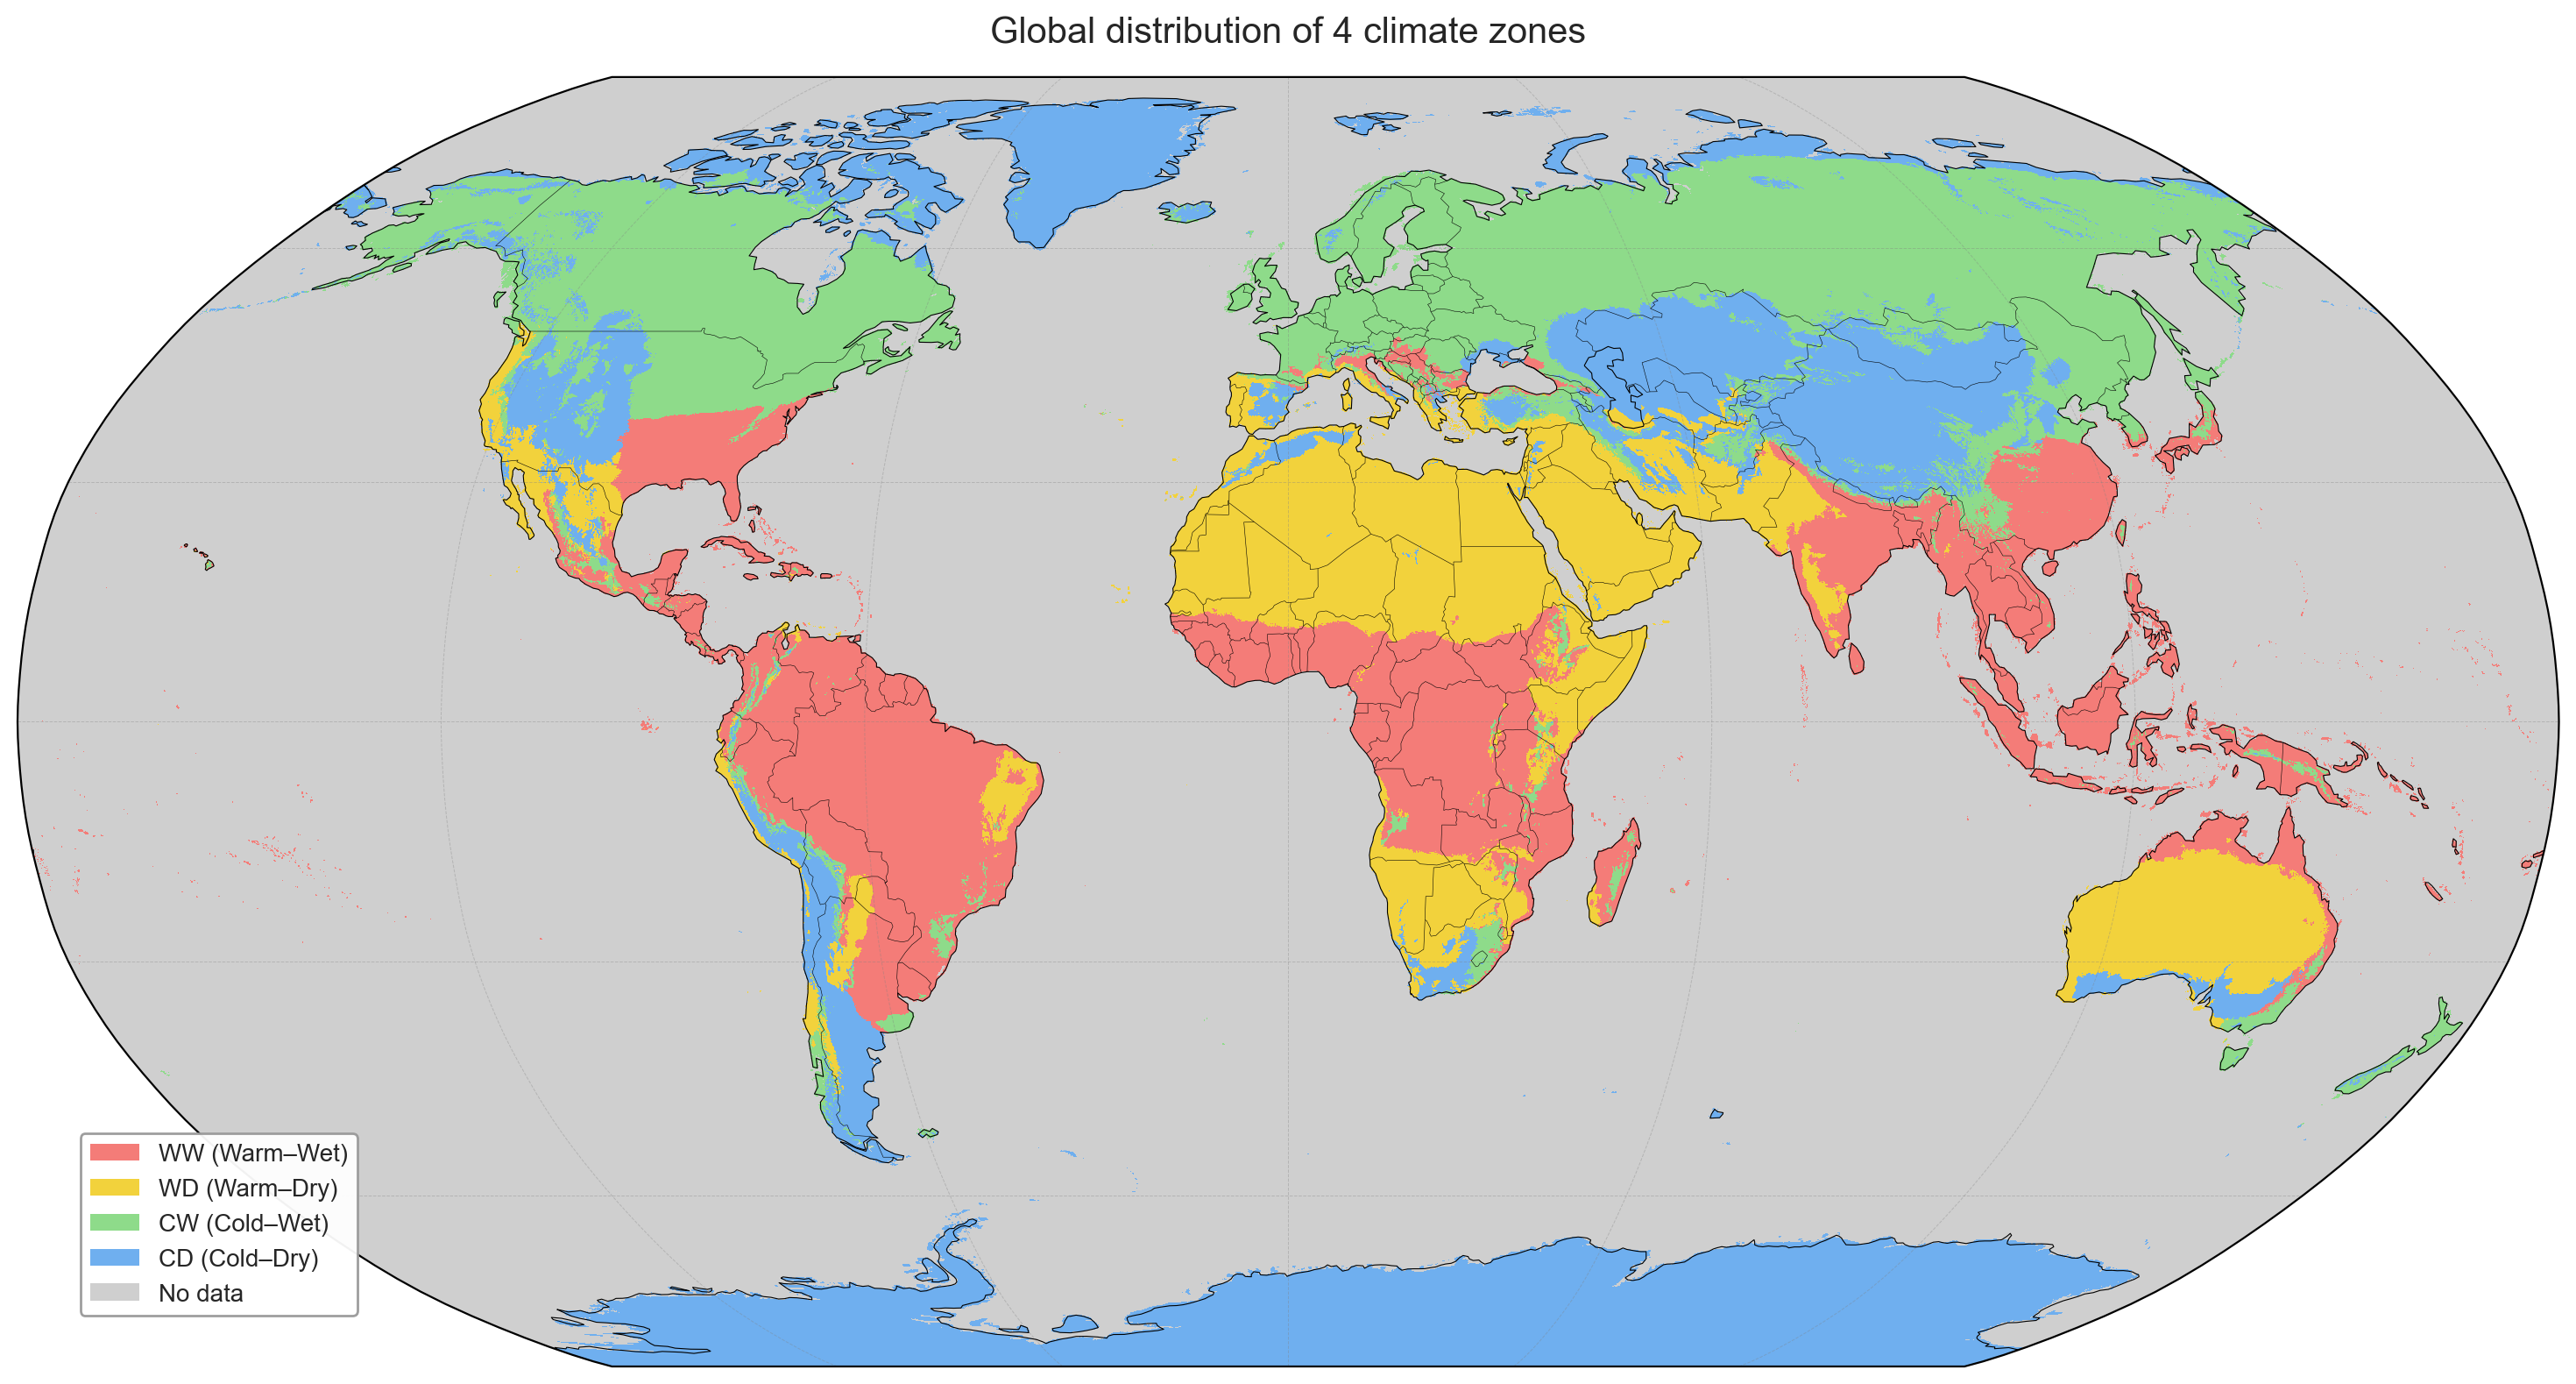

✓ 4分类气候区全球分布图已生成


In [15]:

from matplotlib.patches import Patch


# -----------------------------
# 1. 颜色定义
# -----------------------------
# color_map_4class = {
#     'HW': '#F08A8A',     # Hot-Wet 柔和红
#     'HD': '#F3D36B',     # Hot-Dry 柔和黄
#     'CW': '#8BCF88',     # Cold-Wet 柔和绿
#     'CD': '#8FB6F5',     # Cold-Dry 柔和蓝
#     'Unknown': '#D9D9D9' # 灰色
# }
color_map_4class = {
    'HW': '#F47C78',     # Hot-Wet  珊瑚红
    'HD': '#F2D23C',     # Hot-Dry  亮黄
    'CW': '#8EDB8A',     # Cold-Wet 浅绿
    'CD': '#6FAFEF',     # Cold-Dry 亮蓝
    'Unknown': '#CFCFCF' # No data   浅灰
}

# 类别转数字
zone_to_num = {'Unknown': 0, 'HW': 1, 'HD': 2, 'CW': 3, 'CD': 4}
num_array = np.vectorize(lambda x: zone_to_num.get(x, 0))(climate_4class_values)

# 自定义离散 colormap
colors_list = [
    color_map_4class['Unknown'],
    color_map_4class['HW'],
    color_map_4class['HD'],
    color_map_4class['CW'],
    color_map_4class['CD']
]
cmap_4class = ListedColormap(colors_list)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
norm = BoundaryNorm(bounds, cmap_4class.N)

# -----------------------------
# 2. 网格
# -----------------------------
lon2d, lat2d = np.meshgrid(lons, lats)

# -----------------------------
# 3. 创建投影地图
# -----------------------------
fig = plt.figure(figsize=(16, 8), dpi=200)
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

# 背景和边界
ax.set_facecolor("white")
ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="none", zorder=0)
ax.coastlines(linewidth=0.4, color="black", zorder=3)
ax.add_feature(cfeature.BORDERS, linewidth=0.2, edgecolor="black", zorder=3)

# 外边框兼容写法
if hasattr(ax, "outline_patch"):
    ax.outline_patch.set_linewidth(0.8)
elif hasattr(ax, "spines") and "geo" in ax.spines:
    ax.spines["geo"].set_linewidth(0.8)
    ax.spines["geo"].set_edgecolor("black")

# -----------------------------
# 4. 绘制分类数据
# -----------------------------
mesh = ax.pcolormesh(
    lon2d,
    lat2d,
    num_array,
    cmap=cmap_4class,
    norm=norm,
    transform=ccrs.PlateCarree(),
    shading="auto",
    zorder=1
)

# -----------------------------
# 5. 经纬网
# -----------------------------
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    linewidth=0.35,
    color="gray",
    alpha=0.35,
    linestyle="--"
)

# -----------------------------
# 6. 图例
# -----------------------------
legend_elements = [
    Patch(facecolor=color_map_4class['HW'], edgecolor='none', label='WW (Warm–Wet)'),
    Patch(facecolor=color_map_4class['HD'], edgecolor='none', label='WD (Warm–Dry)'),
    Patch(facecolor=color_map_4class['CW'], edgecolor='none', label='CW (Cold–Wet)'),
    Patch(facecolor=color_map_4class['CD'], edgecolor='none', label='CD (Cold–Dry)'),
    Patch(facecolor=color_map_4class['Unknown'], edgecolor='none', label='No data')
]
ax.legend(
    handles=legend_elements,
    loc='lower left',
    bbox_to_anchor=(0.02, 0.03),
    fontsize=10,
    frameon=True,
    framealpha=0.95,
    facecolor='white',
    edgecolor='0.6'
)

# -----------------------------
# 7. 标题
# -----------------------------
ax.set_title(
    'Global distribution of 4 climate zones',
    fontsize=15,
    pad=14
)

plt.tight_layout()
plt.show()

print("✓ 4分类气候区全球分布图已生成")

## 8. 为模型数据添加气候区标签

In [19]:
# 读取预处理的CSV文件
# classic_csv = Path('data/preprocessed/classic_preprocessed.csv')
# lpj_csv = Path('data/preprocessed/lpj_guess_preprocessed.csv')

classic_csv = Path('./preprocessed/classic_preprocessed_30yr_mean_no0.csv')
lpj_csv = Path('./preprocessed/lpj_guess_preprocessed_30yr_mean_no0.csv')

print("读取预处理数据...")
classic_df = pd.read_csv(classic_csv)
lpj_df = pd.read_csv(lpj_csv)

print(f"CLASSIC数据: {len(classic_df):,} 行")
print(f"LPJ-GUESS数据: {len(lpj_df):,} 行")

# 查看数据结构
print("\nCLASSIC数据列：")
print(classic_df.columns.tolist())
print("\n前5行：")
print(classic_df.head())

读取预处理数据...
CLASSIC数据: 57,690 行
LPJ-GUESS数据: 57,142 行

CLASSIC数据列：
['lat', 'lon', 'precipitation', 'lai', 'evapotrans', 'tran', 'evspsblveg', 'evspsblsoi']

前5行：
     lat    lon  precipitation       lai  evapotrans       tran  evspsblveg  \
0 -55.25 -69.75    1295.743750  0.897974   456.39900  23.021576  121.720700   
1 -55.25 -68.75    1004.722917  0.956527   373.74402  25.167530  116.840454   
2 -55.25 -68.25     906.583333  0.993987   368.79956  33.262510  116.793740   
3 -55.25 -67.25     842.835156  0.875254   352.17703  30.218973  101.964645   
4 -54.75 -70.75    1425.717708  0.963404   502.00520  28.127657  142.457320   

   evspsblsoi  
0   311.65670  
1   231.73602  
2   218.74329  
3   219.99341  
4   331.42020  


In [20]:
# 定义函数：根据经纬度查找气候区
def get_climate_zone(lat, lon, climate_data_array, kg_lats, kg_lons):
    """
    根据经纬度查找对应的气候区
    
    参数:
        lat: 纬度
        lon: 经度
        climate_data_array: 气候分类数据 (numpy array)
        kg_lats: Köppen数据的纬度坐标
        kg_lons: Köppen数据的经度坐标
    
    返回:
        气候区标签 (HW/HD/CW/CD/Unknown)
    """
    # 找到最近的纬度索引
    lat_idx = np.argmin(np.abs(kg_lats - lat))
    
    # 找到最近的经度索引
    lon_idx = np.argmin(np.abs(kg_lons - lon))
    
    # 获取气候区
    zone = climate_data_array[lat_idx, lon_idx]
    
    return zone

print("定义气候区查找函数完成")

定义气候区查找函数完成


In [21]:
# 为CLASSIC数据添加气候区标签
print("为CLASSIC数据添加气候区标签...")
classic_df['climate_zone'] = classic_df.apply(
    lambda row: get_climate_zone(
        row['lat'], 
        row['lon'], 
        climate_4class_values,
        kg_data.lat.values,
        kg_data.lon.values
    ),
    axis=1
)

print("✓ CLASSIC数据标签添加完成")
print("\nCLASSIC气候区分布：")
print(classic_df['climate_zone'].value_counts())
print(f"\n各气候区比例：")
print(classic_df['climate_zone'].value_counts(normalize=True) * 100)

为CLASSIC数据添加气候区标签...
✓ CLASSIC数据标签添加完成

CLASSIC气候区分布：
climate_zone
CW    22052
HW    13134
HD    11739
CD    10765
Name: count, dtype: int64

各气候区比例：
climate_zone
CW    38.224996
HW    22.766511
HD    20.348414
CD    18.660080
Name: proportion, dtype: float64


In [22]:
# 为LPJ-GUESS数据添加气候区标签
print("为LPJ-GUESS数据添加气候区标签...")
lpj_df['climate_zone'] = lpj_df.apply(
    lambda row: get_climate_zone(
        row['lat'], 
        row['lon'], 
        climate_4class_values,
        kg_data.lat.values,
        kg_data.lon.values
    ),
    axis=1
)

print("✓ LPJ-GUESS数据标签添加完成")
print("\nLPJ-GUESS气候区分布：")
print(lpj_df['climate_zone'].value_counts())
print(f"\n各气候区比例：")
print(lpj_df['climate_zone'].value_counts(normalize=True) * 100)

为LPJ-GUESS数据添加气候区标签...
✓ LPJ-GUESS数据标签添加完成

LPJ-GUESS气候区分布：
climate_zone
CW    22044
HW    13112
HD    11733
CD    10253
Name: count, dtype: int64

各气候区比例：
climate_zone
CW    38.577579
HW    22.946344
HD    20.533058
CD    17.943019
Name: proportion, dtype: float64


/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_27629/3365632108.py:39: UserWarning: Glyph 27668 (\N{CJK UNIFIED IDEOGRAPH-6C14}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_27629/3365632108.py:39: UserWarning: Glyph 20505 (\N{CJK UNIFIED IDEOGRAPH-5019}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_27629/3365632108.py:39: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_27629/3365632108.py:39: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_27629/3365632108.py:39: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/i

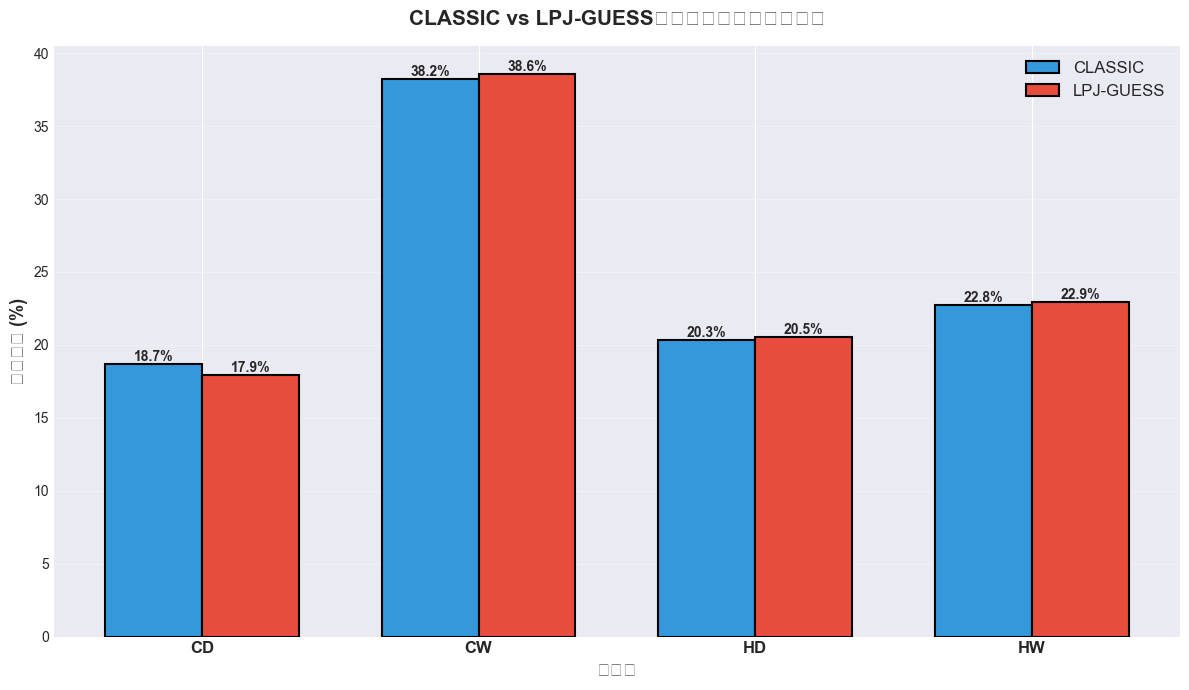

两个模型的气候区样本统计对比
Climate_Zone  CLASSIC_Count  CLASSIC_Pct  LPJ_Count   LPJ_Pct  Diff_Pct
          CD          10765    18.660080      10253 17.943019 -0.717061
          CW          22052    38.224996      22044 38.577579  0.352583
          HD          11739    20.348414      11733 20.533058  0.184644
          HW          13134    22.766511      13112 22.946344  0.179834

总样本数：
  CLASSIC: 57,690
  LPJ-GUESS: 57,142

✓ 模型对比分析完成


In [23]:
# 对比两个模型在各气候区的样本比例
fig, ax = plt.subplots(figsize=(12, 7))

# 计算比例
classic_pct = classic_df['climate_zone'].value_counts(normalize=True).sort_index() * 100
lpj_pct = lpj_df['climate_zone'].value_counts(normalize=True).sort_index() * 100

# 确保两个都有相同的索引
all_zones = sorted(set(classic_pct.index) | set(lpj_pct.index))
classic_pct = classic_pct.reindex(all_zones, fill_value=0)
lpj_pct = lpj_pct.reindex(all_zones, fill_value=0)

# 绘制分组柱状图
x = np.arange(len(all_zones))
width = 0.35

bars1 = ax.bar(x - width/2, classic_pct.values, width, label='CLASSIC', 
               color='#3498db', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, lpj_pct.values, width, label='LPJ-GUESS',
               color='#e74c3c', edgecolor='black', linewidth=1.5)

# 添加数值标签
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1f}%',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('气候区', fontsize=13, fontweight='bold')
ax.set_ylabel('样本比例 (%)', fontsize=13, fontweight='bold')
ax.set_title('CLASSIC vs LPJ-GUESS：各气候区样本比例对比', fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(all_zones, fontsize=12, fontweight='bold')
ax.legend(fontsize=12, loc='upper right', framealpha=0.9, edgecolor='black')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig('output/climate_zones_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 打印详细统计
print("="*80)
print("两个模型的气候区样本统计对比")
print("="*80)
comparison_df = pd.DataFrame({
    'Climate_Zone': all_zones,
    'CLASSIC_Count': [classic_df[classic_df['climate_zone']==z].shape[0] for z in all_zones],
    'CLASSIC_Pct': classic_pct.values,
    'LPJ_Count': [lpj_df[lpj_df['climate_zone']==z].shape[0] for z in all_zones],
    'LPJ_Pct': lpj_pct.values,
    'Diff_Pct': lpj_pct.values - classic_pct.values
})
print(comparison_df.to_string(index=False))

print(f"\n总样本数：")
print(f"  CLASSIC: {len(classic_df):,}")
print(f"  LPJ-GUESS: {len(lpj_df):,}")
print(f"\n✓ 模型对比分析完成")

### 8.3 对比分析：两个模型的气候区差异

/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_27629/75603970.py:45: UserWarning: Glyph 32463 (\N{CJK UNIFIED IDEOGRAPH-7ECF}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_27629/75603970.py:45: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_27629/75603970.py:45: UserWarning: Glyph 32428 (\N{CJK UNIFIED IDEOGRAPH-7EAC}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_27629/75603970.py:45: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) Arial.
  plt.tight_layout()
/Users/mimi/miniconda3/envs/pip39/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 32428 (\N{CJK UNIFIED IDEOGRAPH-7EAC}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mimi/miniconda3/env

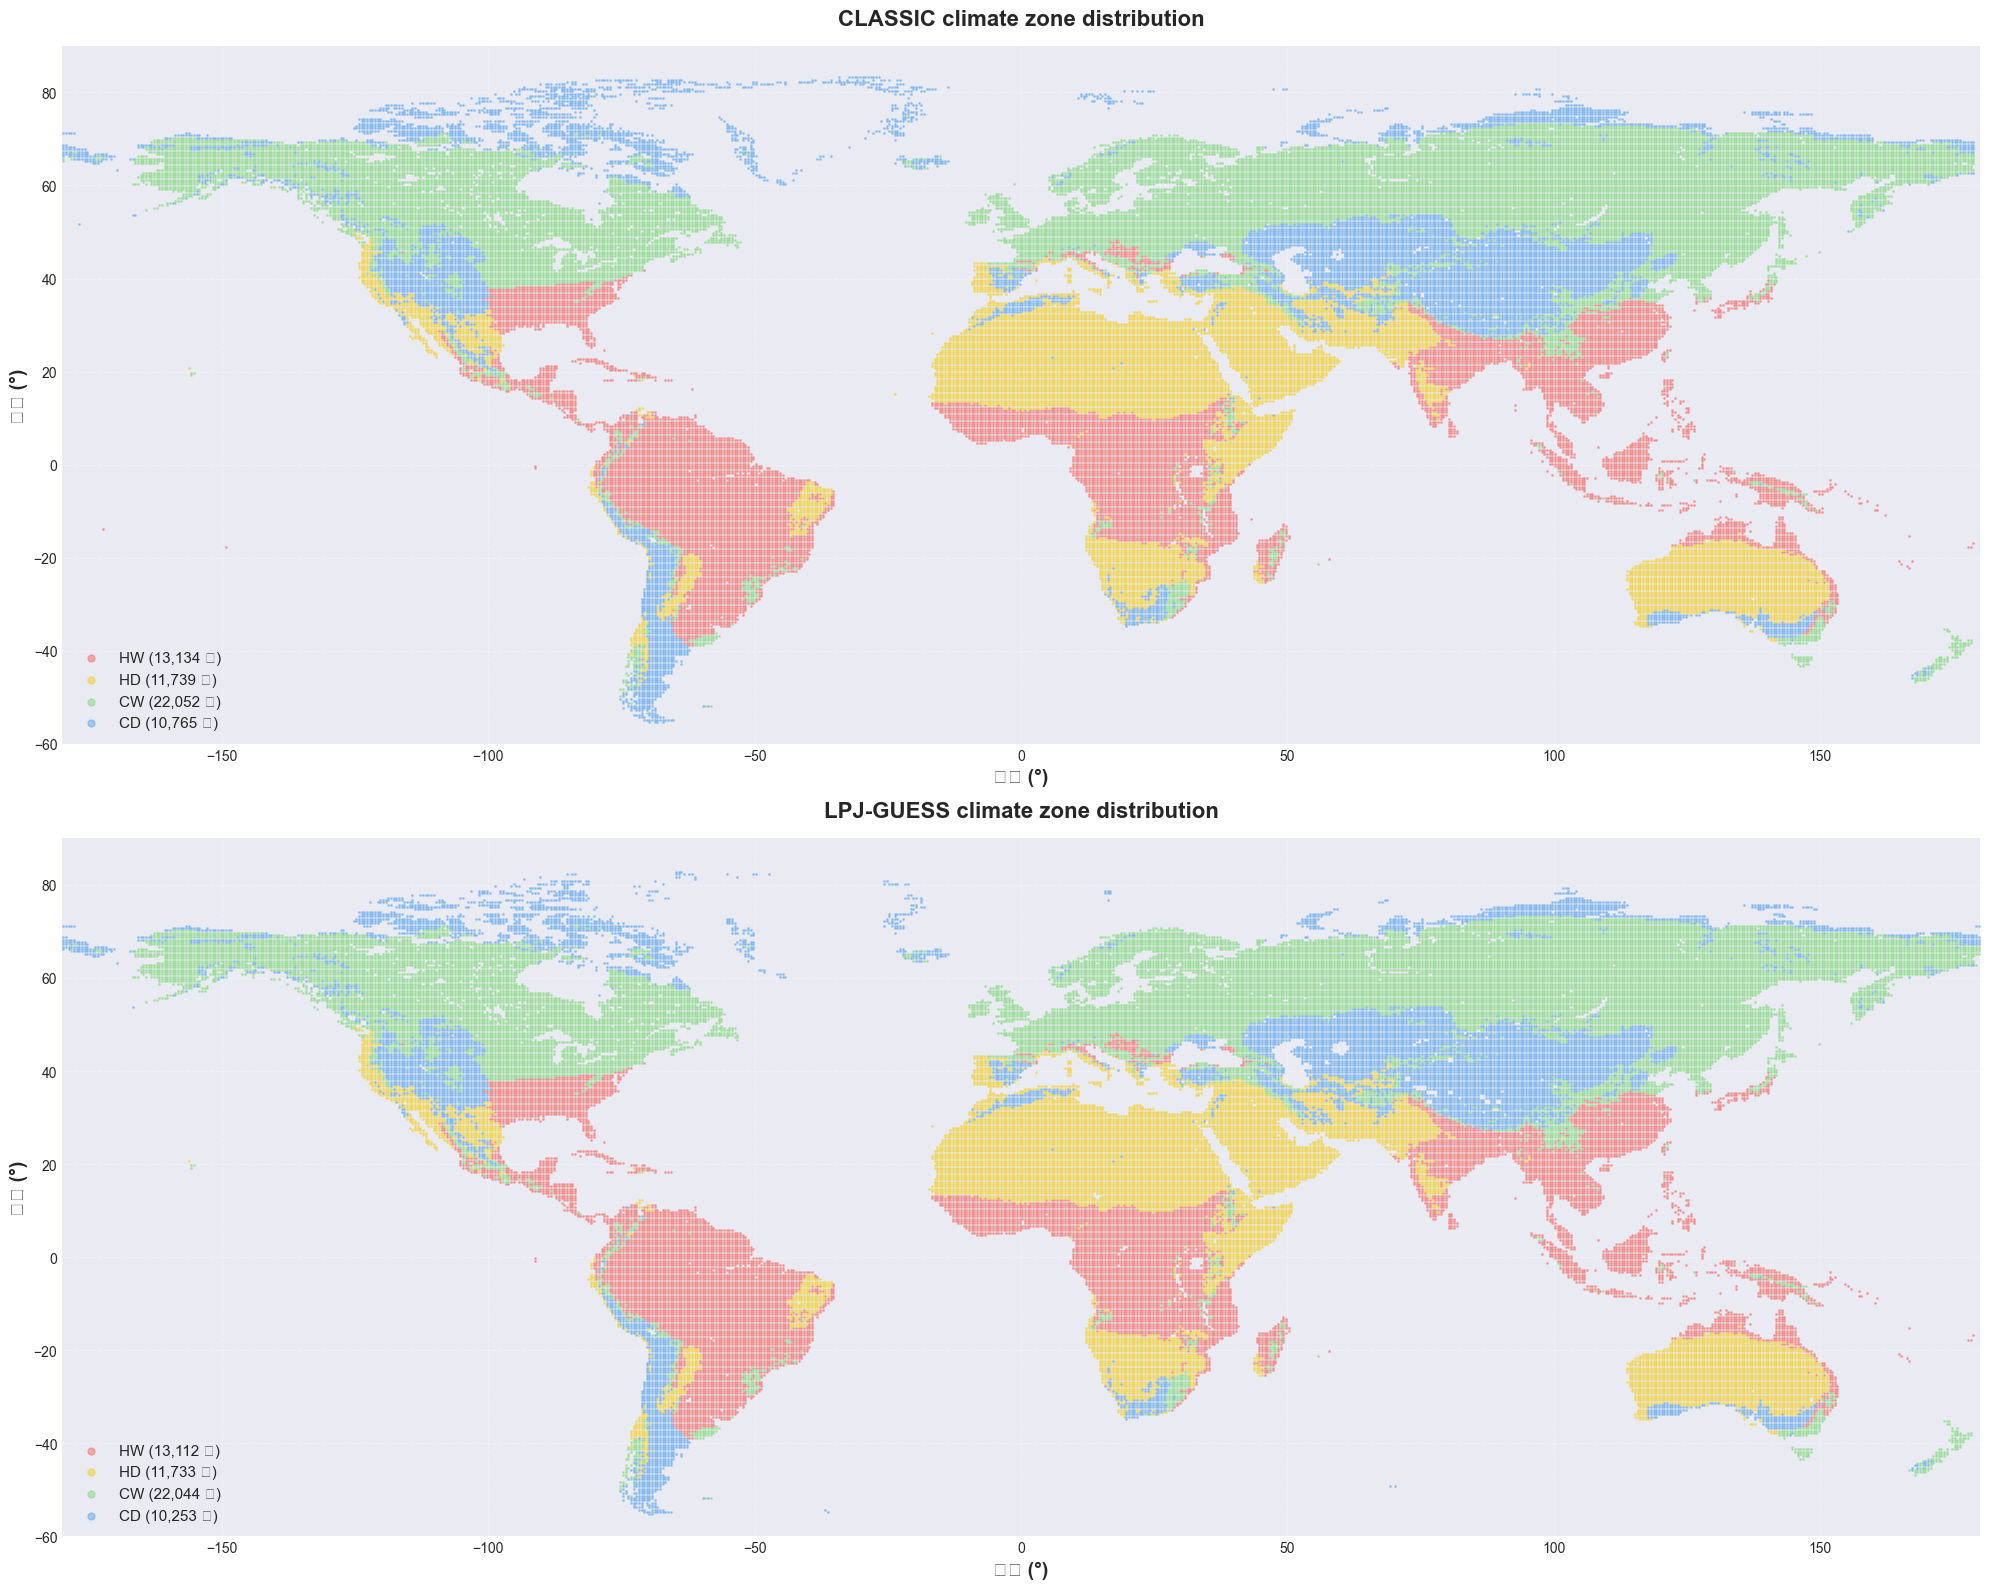

✓ 数据点空间分布图已生成

CLASSIC模型覆盖范围：
  经度: [-179.75, 178.75]
  纬度: [-55.25, 83.25]

LPJ-GUESS模型覆盖范围：
  经度: [-179.75, 179.75]
  纬度: [-55.25, 82.75]


In [24]:
# 在地图上展示CLASSIC和LPJ-GUESS数据点的气候区分布
fig, axes = plt.subplots(2, 1, figsize=(20, 16))

# 使用相同的颜色映射
zone_colors = {
    'HW': color_map_4class['HW'],
    'HD': color_map_4class['HD'],
    'CW': color_map_4class['CW'],
    'CD': color_map_4class['CD'],
    'Unknown': color_map_4class['Unknown']
}

# 1. CLASSIC模型数据点分布
ax1 = axes[0]
for zone, color in zone_colors.items():
    zone_data = classic_df[classic_df['climate_zone'] == zone]
    if len(zone_data) > 0:
        ax1.scatter(zone_data['lon'], zone_data['lat'], 
                   c=color, s=1, alpha=0.6, label=f'{zone} ({len(zone_data):,} 点)')

ax1.set_xlabel('经度 (°)', fontsize=14, fontweight='bold')
ax1.set_ylabel('纬度 (°)', fontsize=14, fontweight='bold')
ax1.set_title('CLASSIC climate zone distribution', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlim(-180, 180)
ax1.set_ylim(-60, 90)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(loc='lower left', fontsize=11, framealpha=0.9, edgecolor='black', markerscale=5)

# 2. LPJ-GUESS模型数据点分布
ax2 = axes[1]
for zone, color in zone_colors.items():
    zone_data = lpj_df[lpj_df['climate_zone'] == zone]
    if len(zone_data) > 0:
        ax2.scatter(zone_data['lon'], zone_data['lat'], 
                   c=color, s=1, alpha=0.6, label=f'{zone} ({len(zone_data):,} 点)')

ax2.set_xlabel('经度 (°)', fontsize=14, fontweight='bold')
ax2.set_ylabel('纬度 (°)', fontsize=14, fontweight='bold')
ax2.set_title('LPJ-GUESS climate zone distribution', fontsize=16, fontweight='bold', pad=15)
ax2.set_xlim(-180, 180)
ax2.set_ylim(-60, 90)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(loc='lower left', fontsize=11, framealpha=0.9, edgecolor='black', markerscale=5)

plt.tight_layout()
# plt.savefig('output/climate_zones_spatial_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 数据点空间分布图已生成")
print(f"\nCLASSIC模型覆盖范围：")
print(f"  经度: [{classic_df['lon'].min():.2f}, {classic_df['lon'].max():.2f}]")
print(f"  纬度: [{classic_df['lat'].min():.2f}, {classic_df['lat'].max():.2f}]")
print(f"\nLPJ-GUESS模型覆盖范围：")
print(f"  经度: [{lpj_df['lon'].min():.2f}, {lpj_df['lon'].max():.2f}]")
print(f"  纬度: [{lpj_df['lat'].min():.2f}, {lpj_df['lat'].max():.2f}]")

### 8.2 在地图上展示标签数据的空间分布

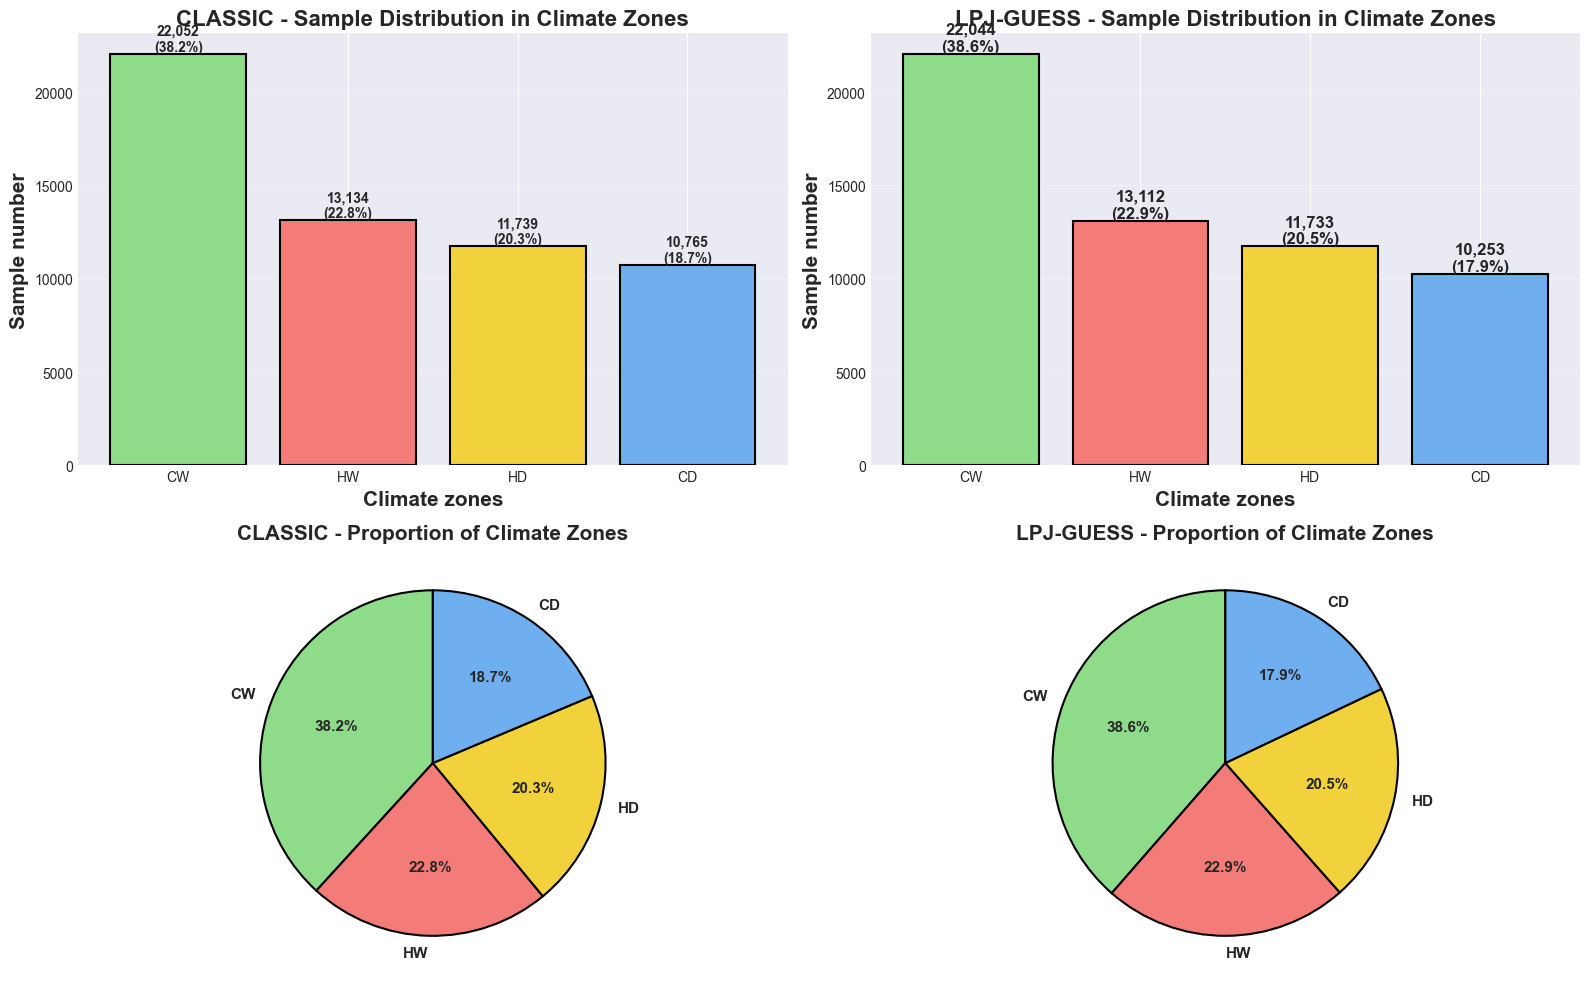

✓ 气候区统计分布图已生成


In [34]:
# 统计两个模型的气候区分布
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. CLASSIC - 柱状图
ax1 = axes[0, 0]
classic_counts = classic_df['climate_zone'].value_counts()
colors = [color_map_4class.get(zone, '#CCCCCC') for zone in classic_counts.index]
bars1 = ax1.bar(classic_counts.index, classic_counts.values, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Climate zones', fontsize=15, fontweight='bold')
ax1.set_ylabel('Sample number', fontsize=15, fontweight='bold')
ax1.set_title('CLASSIC - Sample Distribution in Climate Zones', fontsize=16, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 添加数值标签
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}\n({height/len(classic_df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. LPJ-GUESS - 柱状图
ax2 = axes[0, 1]
lpj_counts = lpj_df['climate_zone'].value_counts()
colors = [color_map_4class.get(zone, '#CCCCCC') for zone in lpj_counts.index]
bars2 = ax2.bar(lpj_counts.index, lpj_counts.values, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Climate zones', fontsize=15, fontweight='bold')
ax2.set_ylabel('Sample number', fontsize=15, fontweight='bold')
ax2.set_title('LPJ-GUESS - Sample Distribution in Climate Zones', fontsize=16, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 添加数值标签
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}\n({height/len(lpj_df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# 3. CLASSIC - 饼图
ax3 = axes[1, 0]
colors_pie = [color_map_4class.get(zone, '#CCCCCC') for zone in classic_counts.index]
wedges, texts, autotexts = ax3.pie(classic_counts.values, labels=classic_counts.index, 
                                     autopct='%1.1f%%', colors=colors_pie,
                                     startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'},
                                     wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
ax3.set_title('CLASSIC - Proportion of Climate Zones', fontsize=15, fontweight='bold')

# 4. LPJ-GUESS - 饼图
ax4 = axes[1, 1]
colors_pie = [color_map_4class.get(zone, '#CCCCCC') for zone in lpj_counts.index]
wedges, texts, autotexts = ax4.pie(lpj_counts.values, labels=lpj_counts.index,
                                     autopct='%1.1f%%', colors=colors_pie,
                                     startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'},
                                     wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
ax4.set_title('LPJ-GUESS - Proportion of Climate Zones', fontsize=15, fontweight='bold')

plt.tight_layout()
# plt.savefig('output/climate_zones_distribution_stats.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 气候区统计分布图已生成")

### 8.1 可视化标签数据的统计分布

## 9. 导出带气候区标签的新CSV

In [26]:
# 创建输出目录
output_dir = Path('preprocessed/preprocessed_with_zones')
output_dir.mkdir(parents=True, exist_ok=True)

# ============================================================================
# 第1步：添加数据质量控制标志（物理不一致性检查）
# ============================================================================
# print("="*80)
# print("第1步：添加数据质量控制标志（物理不一致性检查）")
# print("="*80)

# classic_df["bad_T"]    = classic_df["evapotrans"] < classic_df["tran"]
# classic_df["bad_Esoil"] = classic_df["evapotrans"] < classic_df["evspsblsoi"]
# classic_df["bad_Eveg"]  = classic_df["evapotrans"] < classic_df["evspsblveg"]
# classic_df["bad_any"]   = classic_df[["bad_T", "bad_Esoil", "bad_Eveg"]].any(axis=1)

# lpj_df["bad_T"]    = lpj_df["evapotrans"] < lpj_df["tran"]
# lpj_df["bad_Esoil"] = lpj_df["evapotrans"] < lpj_df["evspsblsoi"]
# lpj_df["bad_Eveg"]  = lpj_df["evapotrans"] < lpj_df["evspsblveg"]
# lpj_df["bad_any"]   = lpj_df[["bad_T", "bad_Esoil", "bad_Eveg"]].any(axis=1)

# print("✓ 物理不一致性检查完成")

# # 统计物理不一致性
# print("\nCLASSIC模型 - 物理不一致性统计:")
# print(f"  总样本数: {len(classic_df):,}")
# print(f"  bad_T (ET < T): {classic_df['bad_T'].sum():,} ({classic_df['bad_T'].sum()/len(classic_df)*100:.2f}%)")
# print(f"  bad_Esoil (ET < Esoil): {classic_df['bad_Esoil'].sum():,} ({classic_df['bad_Esoil'].sum()/len(classic_df)*100:.2f}%)")
# print(f"  bad_Eveg (ET < Eveg): {classic_df['bad_Eveg'].sum():,} ({classic_df['bad_Eveg'].sum()/len(classic_df)*100:.2f}%)")
# print(f"  bad_any (任何不一致): {classic_df['bad_any'].sum():,} ({classic_df['bad_any'].sum()/len(classic_df)*100:.2f}%)")

# print("\nLPJ-GUESS模型 - 物理不一致性统计:")
# print(f"  总样本数: {len(lpj_df):,}")
# print(f"  bad_T (ET < T): {lpj_df['bad_T'].sum():,} ({lpj_df['bad_T'].sum()/len(lpj_df)*100:.2f}%)")
# print(f"  bad_Esoil (ET < Esoil): {lpj_df['bad_Esoil'].sum():,} ({lpj_df['bad_Esoil'].sum()/len(lpj_df)*100:.2f}%)")
# print(f"  bad_Eveg (ET < Eveg): {lpj_df['bad_Eveg'].sum():,} ({lpj_df['bad_Eveg'].sum()/len(lpj_df)*100:.2f}%)")
# print(f"  bad_any (任何不一致): {lpj_df['bad_any'].sum():,} ({lpj_df['bad_any'].sum()/len(lpj_df)*100:.2f}%)")





# ============================================================================
# 第2步：分气候区剔除极值（前1%和后1%）
# ============================================================================
print("\n" + "="*80)
print("第2步：分气候区剔除极值（前1%和后1%）")
print("="*80)

# 定义需要检查极值的变量
value_vars = ['precipitation', 'lai', 'evapotrans', 'tran', 'evspsblveg', 'evspsblsoi']

def mark_outliers_by_zone(df, zones=['HW', 'HD', 'CW', 'CD'], 
                          variables=value_vars, 
                          lower_percentile=1, 
                          upper_percentile=99):
    """
    在每个气候区内，标记每个变量的极值（前1%和后1%）
    
    参数:
        df: DataFrame
        zones: 气候区列表
        variables: 需要检查极值的变量列表
        lower_percentile: 下限百分位（默认1%）
        upper_percentile: 上限百分位（默认99%）
    
    返回:
        df: 添加了outlier标记的DataFrame
    """
    # 初始化outlier列为False
    df['is_outlier'] = False
    
    outlier_stats = []
    
    for zone in zones:
        zone_mask = df['climate_zone'] == zone
        zone_data = df[zone_mask]
        
        if len(zone_data) == 0:
            continue
        
        print(f"\n处理气候区: {zone}")
        print(f"  样本数: {len(zone_data):,}")
        
        zone_outliers = 0
        
        for var in variables:
            # 计算该气候区内该变量的1%和99%分位数
            lower_bound = zone_data[var].quantile(lower_percentile / 100)
            upper_bound = zone_data[var].quantile(upper_percentile / 100)
            
            # 标记极值
            outlier_mask = zone_mask & ((df[var] < lower_bound) | (df[var] > upper_bound))
            df.loc[outlier_mask, 'is_outlier'] = True
            
            n_outliers = outlier_mask.sum()
            zone_outliers += n_outliers
            
            outlier_stats.append({
                'Zone': zone,
                'Variable': var,
                'Lower_Bound': lower_bound,
                'Upper_Bound': upper_bound,
                'N_Outliers': n_outliers,
                'Pct_Outliers': n_outliers / len(zone_data) * 100 if len(zone_data) > 0 else 0
            })
            
            print(f"    {var}: [{lower_bound:.2f}, {upper_bound:.2f}], 极值={n_outliers:,} ({n_outliers/len(zone_data)*100:.2f}%)")
        
        total_zone_outliers = df[zone_mask]['is_outlier'].sum()
        print(f"  该区总极值样本: {total_zone_outliers:,} ({total_zone_outliers/len(zone_data)*100:.2f}%)")
    
    return df, pd.DataFrame(outlier_stats)

# 对CLASSIC数据标记极值
print("\nCLASSIC模型:")
classic_df, classic_outlier_stats = mark_outliers_by_zone(classic_df)

# 对LPJ-GUESS数据标记极值
print("\n" + "-"*80)
print("LPJ-GUESS模型:")
lpj_df, lpj_outlier_stats = mark_outliers_by_zone(lpj_df)

# 统计总体极值情况
print("\n" + "="*80)
print("极值标记汇总:")
print("="*80)
print(f"\nCLASSIC模型:")
print(f"  总样本数: {len(classic_df):,}")
print(f"  极值样本数: {classic_df['is_outlier'].sum():,} ({classic_df['is_outlier'].sum()/len(classic_df)*100:.2f}%)")
print(f"  有效样本数: {(~classic_df['is_outlier']).sum():,} ({(~classic_df['is_outlier']).sum()/len(classic_df)*100:.2f}%)")

print(f"\nLPJ-GUESS模型:")
print(f"  总样本数: {len(lpj_df):,}")
print(f"  极值样本数: {lpj_df['is_outlier'].sum():,} ({lpj_df['is_outlier'].sum()/len(lpj_df)*100:.2f}%)")
print(f"  有效样本数: {(~lpj_df['is_outlier']).sum():,} ({(~lpj_df['is_outlier']).sum()/len(lpj_df)*100:.2f}%)")

# ============================================================================
# 第3步：导出CSV文件
# ============================================================================
print("\n" + "="*80)
print("第3步：导出CSV文件")
print("="*80)

# # 1. 导出完整CLASSIC数据（包含所有样本及所有质量标志）
# classic_output = output_dir / 'classic_with_climate_zones_30y.csv'
# classic_df.to_csv(classic_output, index=False)
# print(f"\n✓ CLASSIC完整数据已导出到: {classic_output}")
# print(f"  文件大小: {classic_output.stat().st_size / 1024 / 1024:.2f} MB")
# print(f"  样本数: {len(classic_df):,}")
# print(f"  列: {list(classic_df.columns)}")

# # 2. 导出完整LPJ-GUESS数据（包含所有样本及所有质量标志）
# lpj_output = output_dir / 'lpj_guess_with_climate_zones_30y.csv'
# lpj_df.to_csv(lpj_output, index=False)
# print(f"\n✓ LPJ-GUESS完整数据已导出到: {lpj_output}")
# print(f"  文件大小: {lpj_output.stat().st_size / 1024 / 1024:.2f} MB")
# print(f"  样本数: {len(lpj_df):,}")
# print(f"  列: {list(lpj_df.columns)}")

# 3. 导出清洗后的CLASSIC数据（仅包含bad_any=False且is_outlier=False的样本）
# classic_clean = classic_df[(~classic_df['bad_any']) & (~classic_df['is_outlier'])].copy()
classic_clean = classic_df[(~classic_df['is_outlier'])].copy()
classic_clean_output = output_dir / 'classic_with_climate_zones_filtered_30yr_mean.csv'
classic_clean.to_csv(classic_clean_output, index=False)


# print(f"\n✓ CLASSIC清洗数据已导出到: {classic_clean_output}")
# print(f"  文件大小: {classic_clean_output.stat().st_size / 1024 / 1024:.2f} MB")
# print(f"  样本数: {len(classic_clean):,} (保留了 {len(classic_clean)/len(classic_df)*100:.2f}%)")
# print(f"  剔除原因统计:")
# print(f"    - 物理不一致 (bad_any=True): {classic_df['bad_any'].sum():,}")
# print(f"    - 极值 (is_outlier=True): {classic_df['is_outlier'].sum():,}")
# print(f"    - 两者都有: {(classic_df['bad_any'] & classic_df['is_outlier']).sum():,}")
# print(f"    - 总剔除: {len(classic_df) - len(classic_clean):,}")

# 4. 导出清洗后的LPJ-GUESS数据（仅包含bad_any=False且is_outlier=False的样本）
# lpj_clean = lpj_df[(~lpj_df['bad_any']) & (~lpj_df['is_outlier'])].copy()




lpj_clean = lpj_df[(~lpj_df['is_outlier'])].copy()
lpj_clean_output = output_dir / 'lpj_guess_with_climate_zones_filtered_30yr_mean.csv'
lpj_clean.to_csv(lpj_clean_output, index=False)

# print(f"\n✓ LPJ-GUESS清洗数据已导出到: {lpj_clean_output}")
# print(f"  文件大小: {lpj_clean_output.stat().st_size / 1024 / 1024:.2f} MB")
# print(f"  样本数: {len(lpj_clean):,} (保留了 {len(lpj_clean)/len(lpj_df)*100:.2f}%)")
# print(f"  剔除原因统计:")
# print(f"    - 物理不一致 (bad_any=True): {lpj_df['bad_any'].sum():,}")
# print(f"    - 极值 (is_outlier=True): {lpj_df['is_outlier'].sum():,}")
# print(f"    - 两者都有: {(lpj_df['bad_any'] & lpj_df['is_outlier']).sum():,}")
# print(f"    - 总剔除: {len(lpj_df) - len(lpj_clean):,}")

# 5. 导出极值统计信息
classic_outlier_stats.to_csv(output_dir / 'classic_outlier_bounds_by_zone.csv', index=False)
lpj_outlier_stats.to_csv(output_dir / 'lpj_outlier_bounds_by_zone.csv', index=False)
print(f"\n✓ 极值边界统计已导出:")
print(f"  - {output_dir / 'classic_outlier_bounds_by_zone.csv'}")
print(f"  - {output_dir / 'lpj_outlier_bounds_by_zone.csv'}")

# ============================================================================
# 汇总报告
# ============================================================================
# print("\n" + "="*80)
# print("任务完成！数据清洗汇总报告")
# print("="*80)

# print("\n生成的文件:")
# print("  完整数据（含所有质量标志）:")
# print("    1. classic_with_climate_zones.csv")
# print("    2. lpj_guess_with_climate_zones.csv")
# print("  清洗数据（仅保留高质量样本）:")
# print("    3. classic_with_climate_zones_filtered.csv")
# print("    4. lpj_guess_with_climate_zones_filtered.csv")
# print("  极值边界统计:")
# print("    5. classic_outlier_bounds_by_zone.csv")
# print("    6. lpj_outlier_bounds_by_zone.csv")

# print("\n数据列说明:")
# print("  原始列: time, lat, lon, precipitation, lai, evapotrans, tran, evspsblveg, evspsblsoi")
# print("  气候区标签: climate_zone (HW/HD/CW/CD/Unknown)")
# print("  质量控制标志:")
# print("    - bad_T: evapotrans < tran (蒸散发 < 蒸腾)")
# print("    - bad_Esoil: evapotrans < evspsblsoi (蒸散发 < 土壤蒸发)")
# print("    - bad_Eveg: evapotrans < evspsblveg (蒸散发 < 植被蒸发)")
# print("    - bad_any: 以上任一条件为True")
# print("    - is_outlier: 在该气候区内为极值（前1%或后1%）")

# print("\n气候区标签说明:")
# print("  HW - 热湿 (Hot-Wet): 热带气候，高温高湿")
# print("  HD - 热干 (Hot-Dry): 干旱气候，水分限制")
# print("  CW - 冷湿 (Cold-Wet): 温带/寒带无干季，能量限制")
# print("  CD - 冷干 (Cold-Dry): 温带/寒带有干季或极地")

# print("\n数据质量汇总:")
# print("\nCLASSIC模型:")
# print(f"  原始样本: {len(classic_df):,}")
# print(f"  物理不一致: {classic_df['bad_any'].sum():,} ({classic_df['bad_any'].sum()/len(classic_df)*100:.2f}%)")
# print(f"  极值: {classic_df['is_outlier'].sum():,} ({classic_df['is_outlier'].sum()/len(classic_df)*100:.2f}%)")
# print(f"  清洗后样本: {len(classic_clean):,} ({len(classic_clean)/len(classic_df)*100:.2f}%)")

# print("\nLPJ-GUESS模型:")
# print(f"  原始样本: {len(lpj_df):,}")
# print(f"  物理不一致: {lpj_df['bad_any'].sum():,} ({lpj_df['bad_any'].sum()/len(lpj_df)*100:.2f}%)")
# print(f"  极值: {lpj_df['is_outlier'].sum():,} ({lpj_df['is_outlier'].sum()/len(lpj_df)*100:.2f}%)")
# print(f"  清洗后样本: {len(lpj_clean):,} ({len(lpj_clean)/len(lpj_df)*100:.2f}%)")

print("\n下一步：可以使用这些带标签的数据进行分区GSA分析")
print("  - 使用完整数据集 (*_with_climate_zones.csv) → 可查看所有质量标志")
print("  - 使用清洗数据集 (*_filtered.csv) → 高质量GSA分析")


第2步：分气候区剔除极值（前1%和后1%）

CLASSIC模型:

处理气候区: HW
  样本数: 13,134
    precipitation: [622.49, 3861.01], 极值=264 (2.01%)
    lai: [0.65, 6.86], 极值=264 (2.01%)
    evapotrans: [457.74, 1520.07], 极值=264 (2.01%)
    tran: [102.59, 721.47], 极值=264 (2.01%)
    evspsblveg: [40.83, 769.33], 极值=264 (2.01%)
    evspsblsoi: [87.30, 500.27], 极值=264 (2.01%)
  该区总极值样本: 1,087 (8.28%)

处理气候区: HD
  样本数: 11,739
    precipitation: [2.58, 1326.59], 极值=236 (2.01%)
    lai: [0.00, 2.88], 极值=118 (1.01%)
    evapotrans: [4.03, 758.78], 极值=236 (2.01%)
    tran: [0.00, 290.91], 极值=118 (1.01%)
    evspsblveg: [-0.00, 190.10], 极值=236 (2.01%)
    evspsblsoi: [4.02, 473.99], 极值=236 (2.01%)
  该区总极值样本: 667 (5.68%)

处理气候区: CW
  样本数: 22,052
    precipitation: [219.20, 2155.59], 极值=442 (2.00%)
    lai: [0.01, 4.73], 极值=442 (2.00%)
    evapotrans: [111.54, 908.85], 极值=442 (2.00%)
    tran: [0.46, 383.75], 极值=442 (2.00%)
    evspsblveg: [1.82, 345.76], 极值=442 (2.00%)
    evspsblsoi: [35.47, 377.85], 极值=442 (2.00%)
  该区总极值样本: 1,4

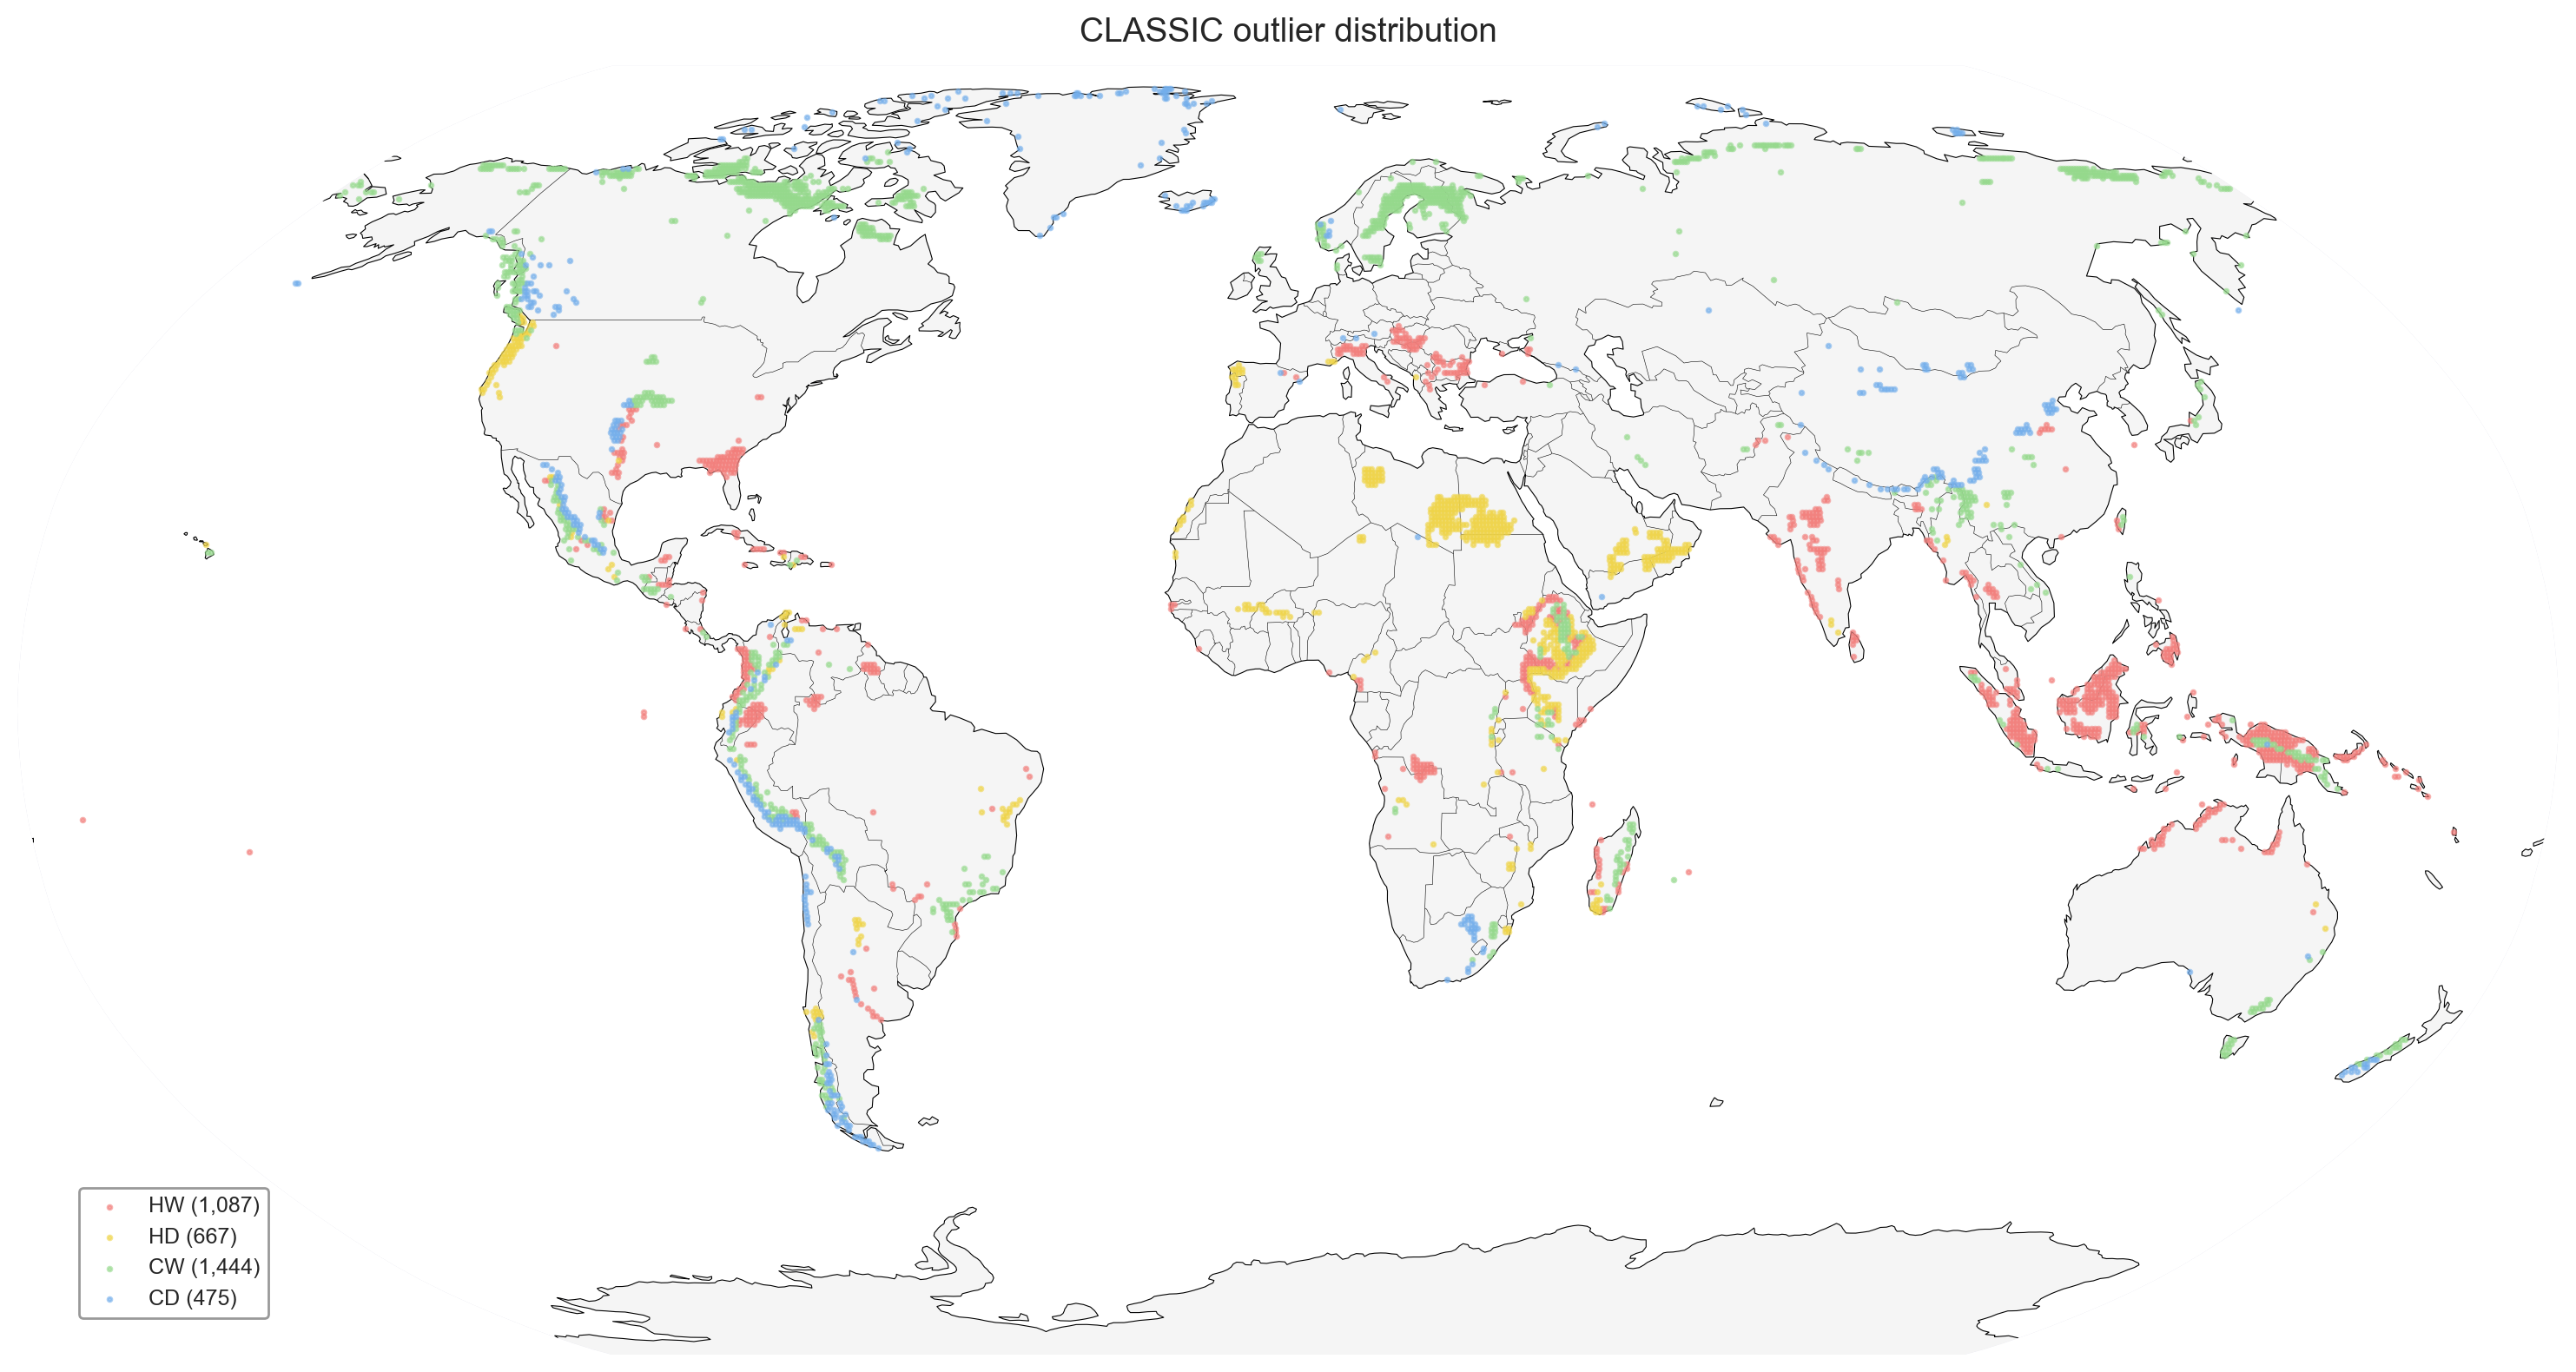

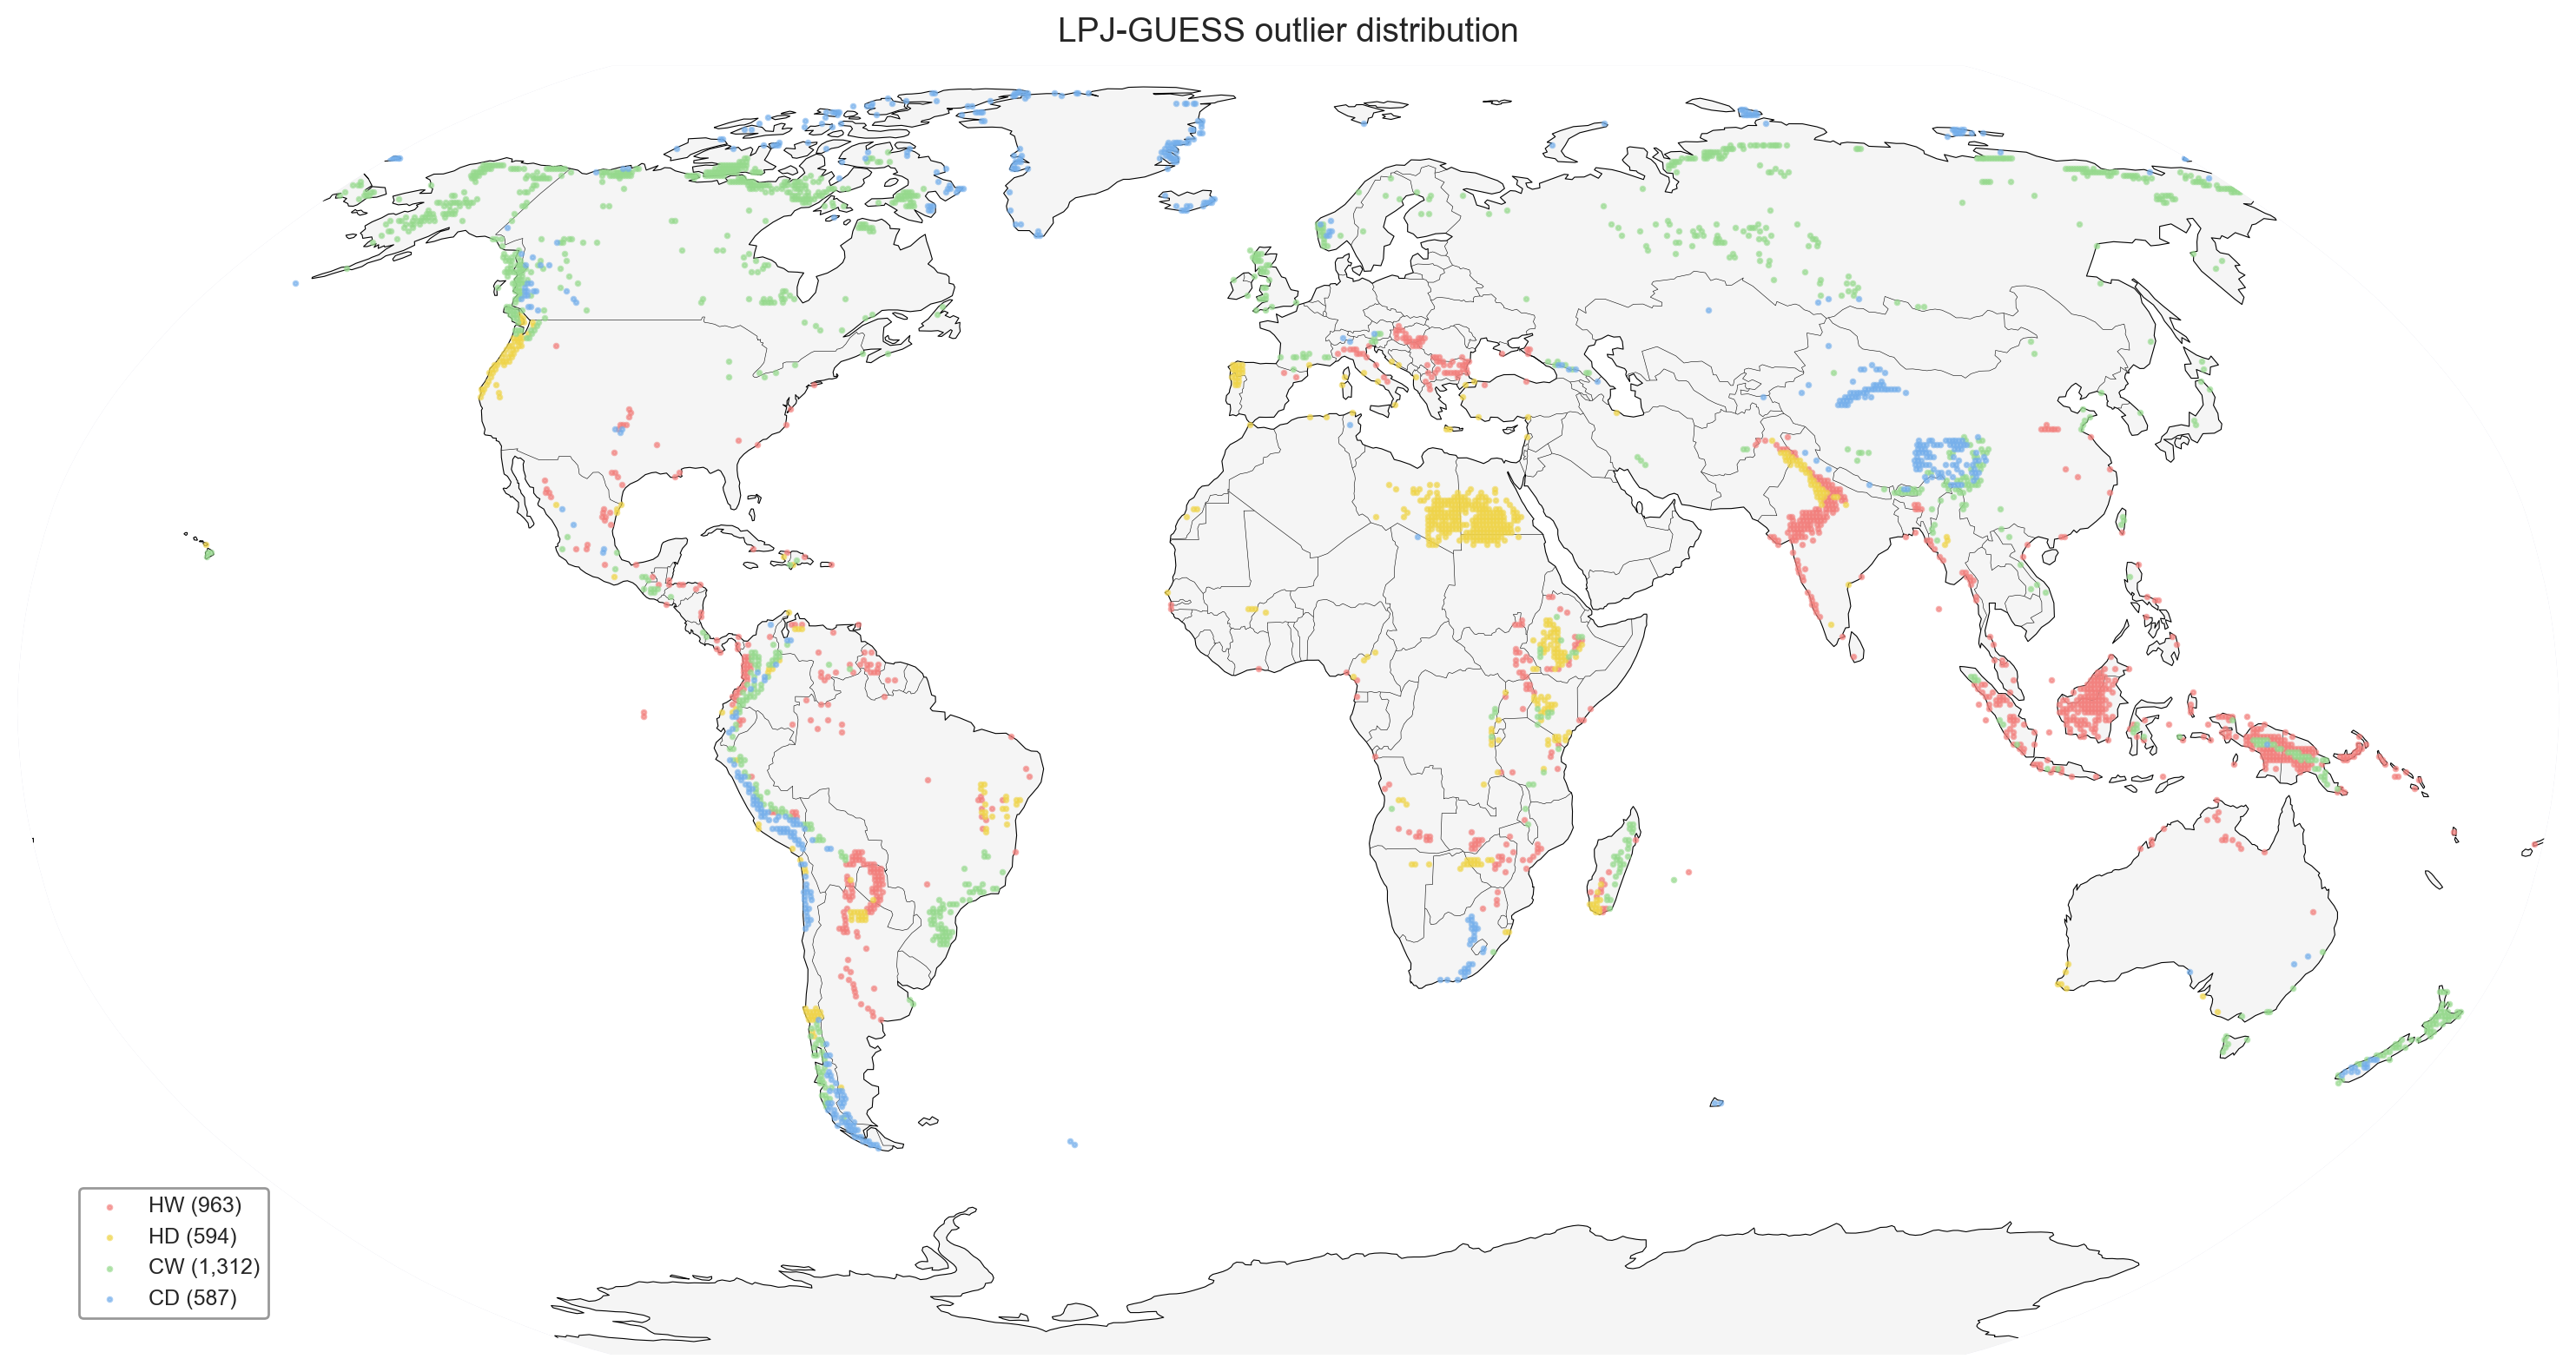

In [27]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_outliers_on_map(df, model_name, zone_colors=None, point_size=3, alpha=0.6):
    """
    在全球地图上绘制极值点
    df 需要包含:
      - lon
      - lat
      - climate_zone
      - is_outlier
    """
    if zone_colors is None:
        zone_colors = {
            'HW': '#F27D7A',
            'HD': '#EFD447',
            'CW': '#95D98C',
            'CD': '#73AEEB',
            'Unknown': '#BFBFBF'
        }

    outliers = df[df['is_outlier']].copy()

    fig = plt.figure(figsize=(16, 8), dpi=200)
    ax = plt.axes(projection=ccrs.Robinson())
    ax.set_global()

    ax.add_feature(cfeature.OCEAN, facecolor='white', edgecolor='none', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='#F5F5F5', edgecolor='none', zorder=0)
    ax.coastlines(linewidth=0.4, color='black', zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2, edgecolor='black', zorder=1)

    # 画不同气候区的极值点
    for zone, color in zone_colors.items():
        sub = outliers[outliers['climate_zone'] == zone]
        if len(sub) == 0:
            continue

        ax.scatter(
            sub['lon'],
            sub['lat'],
            s=point_size,
            color=color,
            alpha=alpha,
            transform=ccrs.PlateCarree(),
            label=f'{zone} ({len(sub):,})',
            zorder=2
        )

    ax.set_title(f'{model_name} outlier distribution', fontsize=14, pad=10)

    ax.legend(
        loc='lower left',
        bbox_to_anchor=(0.02, 0.02),
        fontsize=9,
        frameon=True,
        facecolor='white',
        edgecolor='0.5'
    )

    plt.tight_layout()
    plt.show()

plot_outliers_on_map(classic_df, 'CLASSIC')
plot_outliers_on_map(lpj_df, 'LPJ-GUESS')

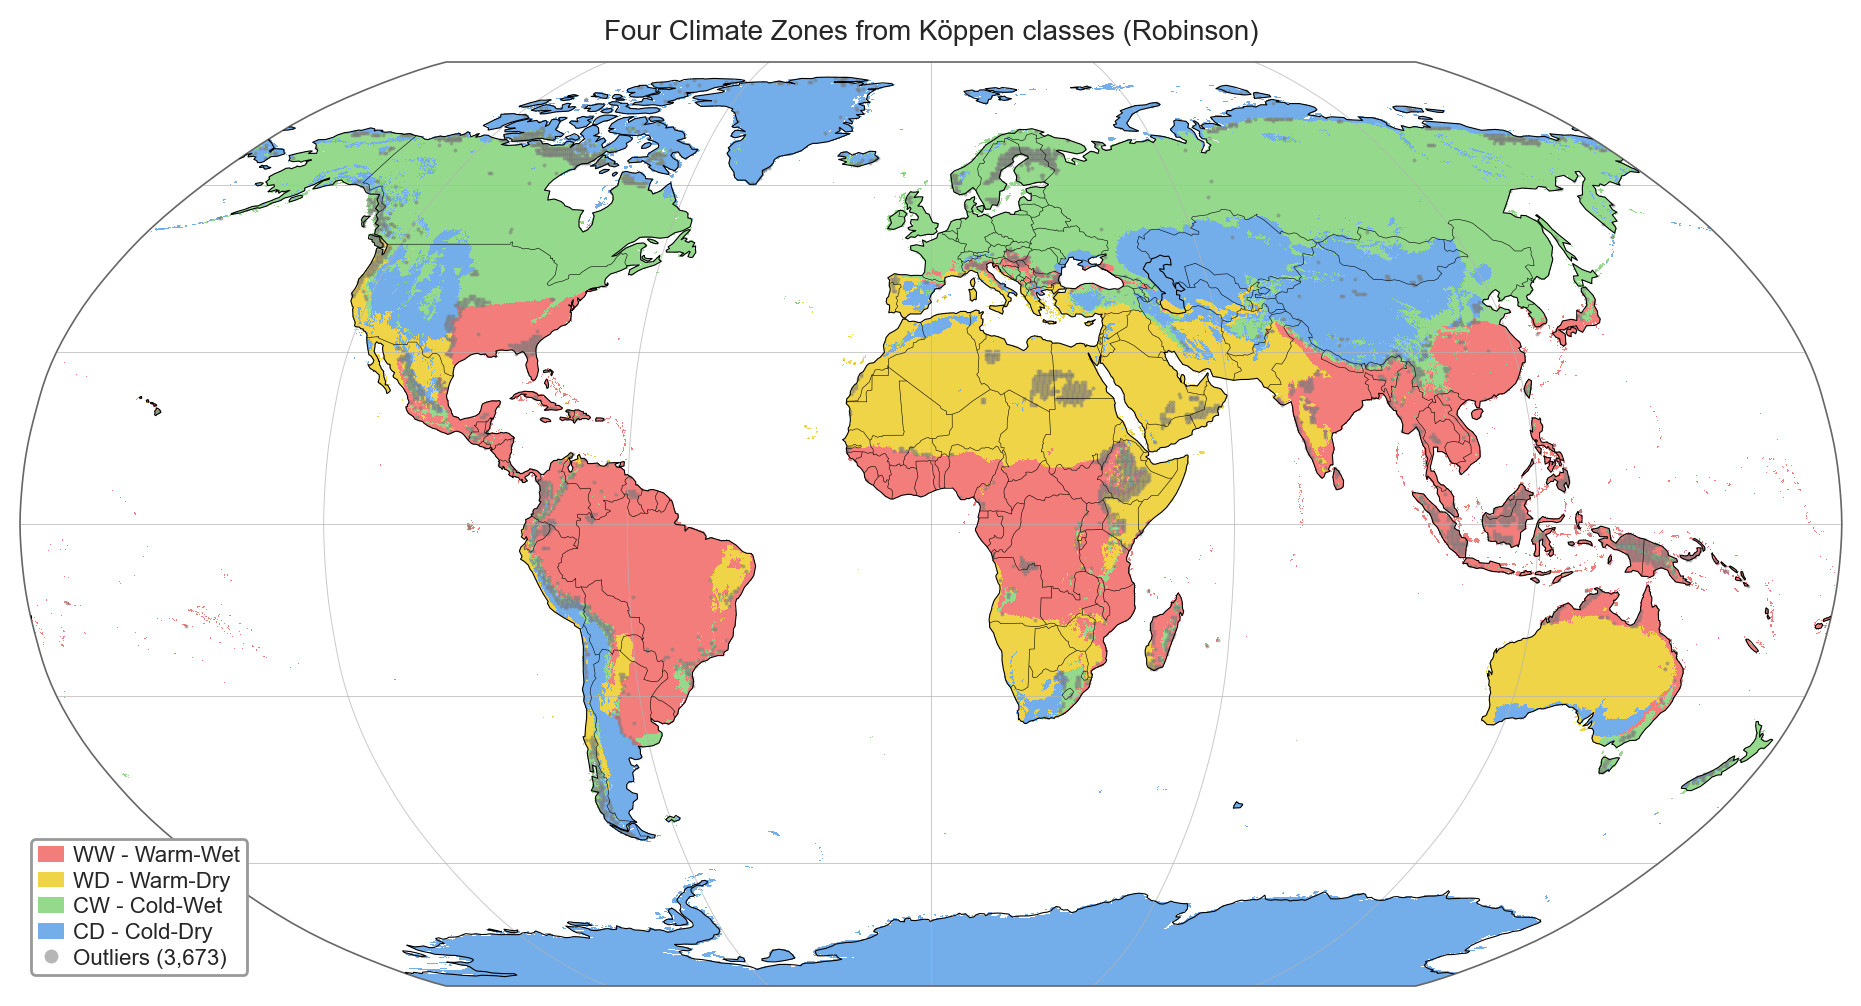

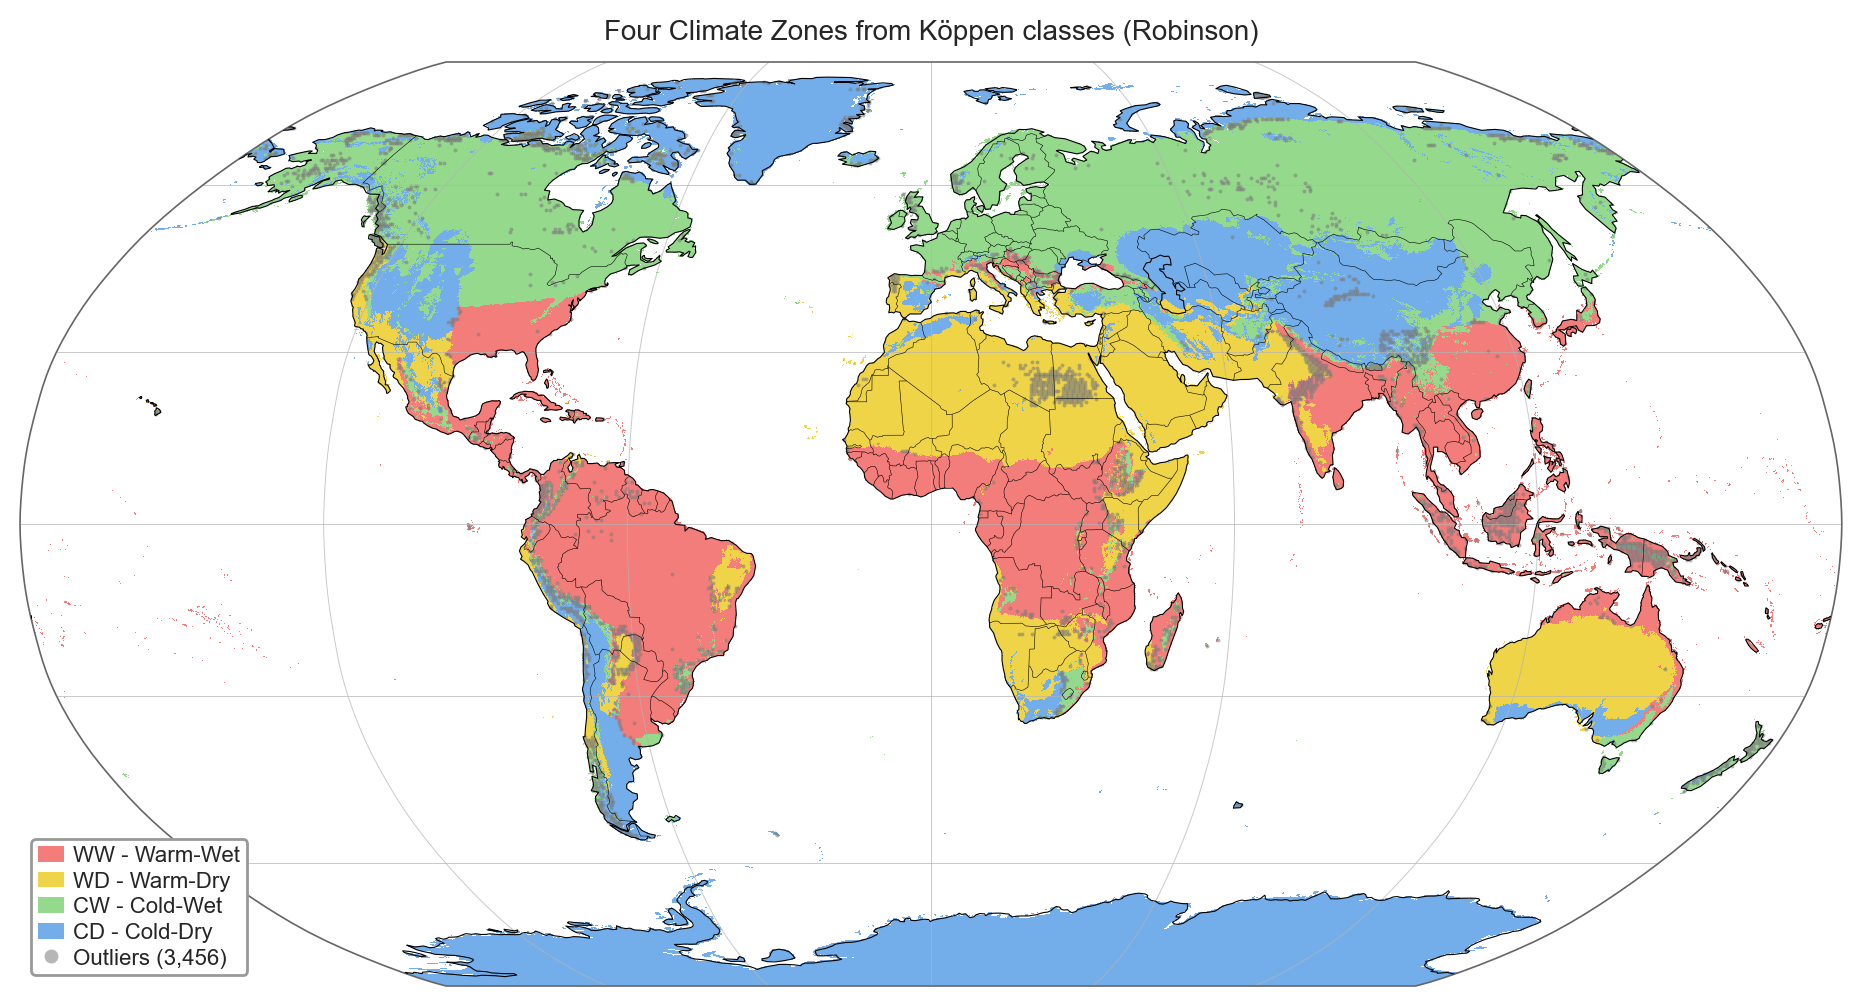

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D


def plot_climate_map_with_outliers(
    climate_4class_values,
    lons,
    lats,
    df,
    model_name="CLASSIC",
    outlier_color="#7A7A7A",
    outlier_size=2.0,
    outlier_alpha=0.55
):
    color_map_4class = {
        'HW': '#F27D7A',
        'HD': '#EFD447',
        'CW': '#95D98C',
        'CD': '#73AEEB',
        'Unknown': (1, 1, 1, 0)
    }

    zone_to_num = {'Unknown': 0, 'HW': 1, 'HD': 2, 'CW': 3, 'CD': 4}
    num_array = np.vectorize(lambda x: zone_to_num.get(x, 0))(climate_4class_values)

    colors_list = [
        (1, 1, 1, 0),
        color_map_4class['HW'],
        color_map_4class['HD'],
        color_map_4class['CW'],
        color_map_4class['CD']
    ]
    cmap_4class = ListedColormap(colors_list)
    bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
    norm = BoundaryNorm(bounds, cmap_4class.N)

    lon2d, lat2d = np.meshgrid(lons, lats)
    outliers = df[df["is_outlier"]].copy()

    fig = plt.figure(figsize=(12, 6), dpi=200)
    ax = plt.axes(projection=ccrs.Robinson())
    ax.set_global()

    ax.add_feature(cfeature.OCEAN, facecolor='white', edgecolor='none', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='none', zorder=0)

    ax.pcolormesh(
        lon2d,
        lat2d,
        num_array,
        cmap=cmap_4class,
        norm=norm,
        transform=ccrs.PlateCarree(),
        shading='auto',
        zorder=1
    )

    ax.scatter(
        outliers["lon"],
        outliers["lat"],
        s=outlier_size,
        color=outlier_color,
        alpha=outlier_alpha,
        linewidth=0,
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    ax.coastlines(linewidth=0.4, color='black', zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2, edgecolor='black', zorder=3)

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,
        linewidth=0.35,
        color='0.7',
        alpha=0.7,
        linestyle='-',
        zorder=2
    )

    # 关键：给外边框一个可见的 geo spine
    if hasattr(ax, "spines") and "geo" in ax.spines:
        ax.spines["geo"].set_visible(True)
        ax.spines["geo"].set_linewidth(0.6)
        ax.spines["geo"].set_edgecolor("0.4")

    legend_elements = [
        Patch(facecolor=color_map_4class['HW'], edgecolor='none', label='WW - Warm-Wet'),
        Patch(facecolor=color_map_4class['HD'], edgecolor='none', label='WD - Warm-Dry'),
        Patch(facecolor=color_map_4class['CW'], edgecolor='none', label='CW - Cold-Wet'),
        Patch(facecolor=color_map_4class['CD'], edgecolor='none', label='CD - Cold-Dry'),
        Line2D(
            [0], [0],
            marker='o',
            color='none',
            markerfacecolor=outlier_color,
            markeredgecolor='none',
            markersize=5,
            alpha=outlier_alpha,
            label=f'Outliers ({len(outliers):,})'
        )
    ]

    ax.legend(
        handles=legend_elements,
        loc='lower left',
        fontsize=8,
        frameon=True,
        framealpha=1,
        facecolor='white',
        edgecolor='0.6',
        borderpad=0.3,
        labelspacing=0.25,
        handlelength=1.2,
        handletextpad=0.4
    )

    ax.set_title('Four Climate Zones from Köppen classes (Robinson)', fontsize=10, pad=8)

    # 不要用 tight_layout，很多时候会把椭圆边界挤坏
    plt.show()


plot_climate_map_with_outliers(
    climate_4class_values=climate_4class_values,
    lons=lons,
    lats=lats,
    df=classic_df,
    model_name="CLASSIC"
)

plot_climate_map_with_outliers(
    climate_4class_values=climate_4class_values,
    lons=lons,
    lats=lats,
    df=lpj_df,
    model_name="LPJ-GUESS"
)

In [38]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D

def plot_zoned_points_2x2(classic_df, lpj_df, point_size=1.5, alpha=0.55):
    color_map_4class = {
        'HW': '#F27D7A',
        'HD': '#EFD447',
        'CW': '#95D98C',
        'CD': '#73AEEB',
        'Unknown': '#BFBFBF'
    }

    zone_label_map = {
        'HW': 'WW - Warm-Wet',
        'HD': 'WD - Warm-Dry',
        'CW': 'CW - Cold-Wet',
        'CD': 'CD - Cold-Dry'
    }

    fig, axes = plt.subplots(
        2, 2,
        figsize=(16, 10),
        dpi=200,
        subplot_kw={'projection': ccrs.Robinson()}
    )

    plot_specs = [
        (axes[0, 0], classic_df, "CLASSIC zoned samples"),
        (axes[0, 1], classic_df[~classic_df["is_outlier"]], "CLASSIC after removing outliers"),
        (axes[1, 0], lpj_df, "LPJ-GUESS zoned samples"),
        (axes[1, 1], lpj_df[~lpj_df["is_outlier"]], "LPJ-GUESS after removing outliers"),
    ]

    for ax, df_plot, title in plot_specs:
        ax.set_global()
        ax.add_feature(cfeature.OCEAN, facecolor='white', edgecolor='none', zorder=0)
        ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='none', zorder=0)
        ax.coastlines(linewidth=0.35, color='black', zorder=3)
        ax.add_feature(cfeature.BORDERS, linewidth=0.2, edgecolor='black', zorder=3)

        ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=False,
            linewidth=0.3,
            color='0.75',
            alpha=0.6,
            linestyle='-',
            zorder=1
        )

        if hasattr(ax, "spines") and "geo" in ax.spines:
            ax.spines["geo"].set_visible(True)
            ax.spines["geo"].set_linewidth(0.5)
            ax.spines["geo"].set_edgecolor("0.4")

        for zone in ['HW', 'HD', 'CW', 'CD']:
            sub = df_plot[df_plot["climate_zone"] == zone]
            if len(sub) == 0:
                continue

            ax.scatter(
                sub["lon"],
                sub["lat"],
                s=point_size,
                color=color_map_4class[zone],
                alpha=alpha,
                linewidth=0,
                transform=ccrs.PlateCarree(),
                zorder=2
            )

        ax.set_title(title, fontsize=15, pad=6)

    legend_elements = [
        Line2D([0], [0], marker='o', color='none',
               markerfacecolor=color_map_4class[z], markeredgecolor='none',
               markersize=6, label=zone_label_map[z])
        for z in ['HW', 'HD', 'CW', 'CD']
    ]

    fig.legend(
        handles=legend_elements,
        loc='lower center',
        ncol=4,
        fontsize=15,
        frameon=True,
        framealpha=1,
        facecolor='white',
        edgecolor='0.6',
        bbox_to_anchor=(0.5, 0.03)
    )

    plt.subplots_adjust(wspace=0.03, hspace=0.08, bottom=0.1)
    plt.show()

plot_zoned_points_2x2(classic_df, lpj_df)

   zone_code     zone_label  count    pct      model                  dataset
0         HW  WW - Warm-Wet  13134  22.77    CLASSIC                      raw
1         HD  WD - Warm-Dry  11739  20.35    CLASSIC                      raw
2         CW  CW - Cold-Wet  22052  38.22    CLASSIC                      raw
3         CD  CD - Cold-Dry  10765  18.66    CLASSIC                      raw
4    Unknown        Unknown      0   0.00    CLASSIC                      raw
5         HW  WW - Warm-Wet  13112  22.95  LPJ-GUESS                      raw
6         HD  WD - Warm-Dry  11733  20.53  LPJ-GUESS                      raw
7         CW  CW - Cold-Wet  22044  38.58  LPJ-GUESS                      raw
8         CD  CD - Cold-Dry  10253  17.94  LPJ-GUESS                      raw
9    Unknown        Unknown      0   0.00  LPJ-GUESS                      raw
10        HW  WW - Warm-Wet  12047  22.30    CLASSIC  after removing outliers
11        HD  WD - Warm-Dry  11072  20.50    CLASSIC  after remo